In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
import os
import itertools
from joblib import Parallel, delayed
from collections import Counter
from skimage.filters import frangi

In [5]:
folder_path = r"C:\Users\PC-LAB1\img_processing_lab\project_1_crack_segmentation\data\train\images"

# List to hold dictionaries with 'name' and 'path'
image_files_list = []

# Valid image extensions
valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

for filename in os.listdir(folder_path):
    if filename.lower().endswith(valid_extensions):
        full_path = os.path.join(folder_path, filename)
        
        # Append name and path to the list
        image_files_list.append({
            "name": filename,
            "path": full_path
        })

# Inspect the first few entries
for item in image_files_list[:5]:
    print(item)

print(f"\nTotal image paths collected: {len(image_files_list)}")

{'name': 'CFD_002.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\images\\CFD_002.jpg'}
{'name': 'CFD_003.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\images\\CFD_003.jpg'}
{'name': 'CFD_004.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\images\\CFD_004.jpg'}
{'name': 'CFD_005.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\images\\CFD_005.jpg'}
{'name': 'CFD_006.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\images\\CFD_006.jpg'}

Total image paths collected: 9603


In [6]:
folder_path_masks = r"C:\Users\PC-LAB1\img_processing_lab\project_1_crack_segmentation\data\train\masks"

# List to hold dictionaries with 'name' and 'path'
mask_files_list = []

# Valid image extensions
valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

for filename in os.listdir(folder_path_masks):
    if filename.lower().endswith(valid_extensions):
        full_path = os.path.join(folder_path_masks, filename)
        
        # Append name and path to the list
        mask_files_list.append({
            "name": filename,
            "path": full_path
        })

# Inspect the first few entries
for item in mask_files_list[:5]:
    print(item)

print(f"\nTotal image paths collected: {len(mask_files_list)}")

{'name': 'CFD_002.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\masks\\CFD_002.jpg'}
{'name': 'CFD_003.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\masks\\CFD_003.jpg'}
{'name': 'CFD_004.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\masks\\CFD_004.jpg'}
{'name': 'CFD_005.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\masks\\CFD_005.jpg'}
{'name': 'CFD_006.jpg', 'path': 'C:\\Users\\PC-LAB1\\img_processing_lab\\project_1_crack_segmentation\\data\\train\\masks\\CFD_006.jpg'}

Total image paths collected: 9603


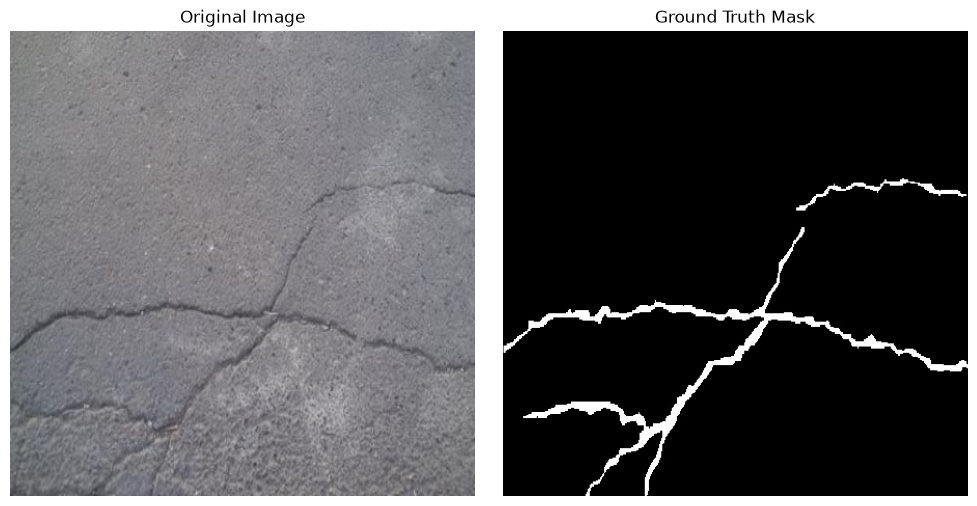

In [7]:
# Grab the first pair (or index 0)
# Adjust access depending on if your list stores dicts {'path': ...} or strings directly
sample_img_path = image_files_list[0]['path'] if isinstance(image_files_list[0], dict) else image_files_list[0]
sample_mask_path = mask_files_list[0]['path'] if isinstance(mask_files_list[0], dict) else mask_files_list[0]

# Read image and mask
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for matplotlib

mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

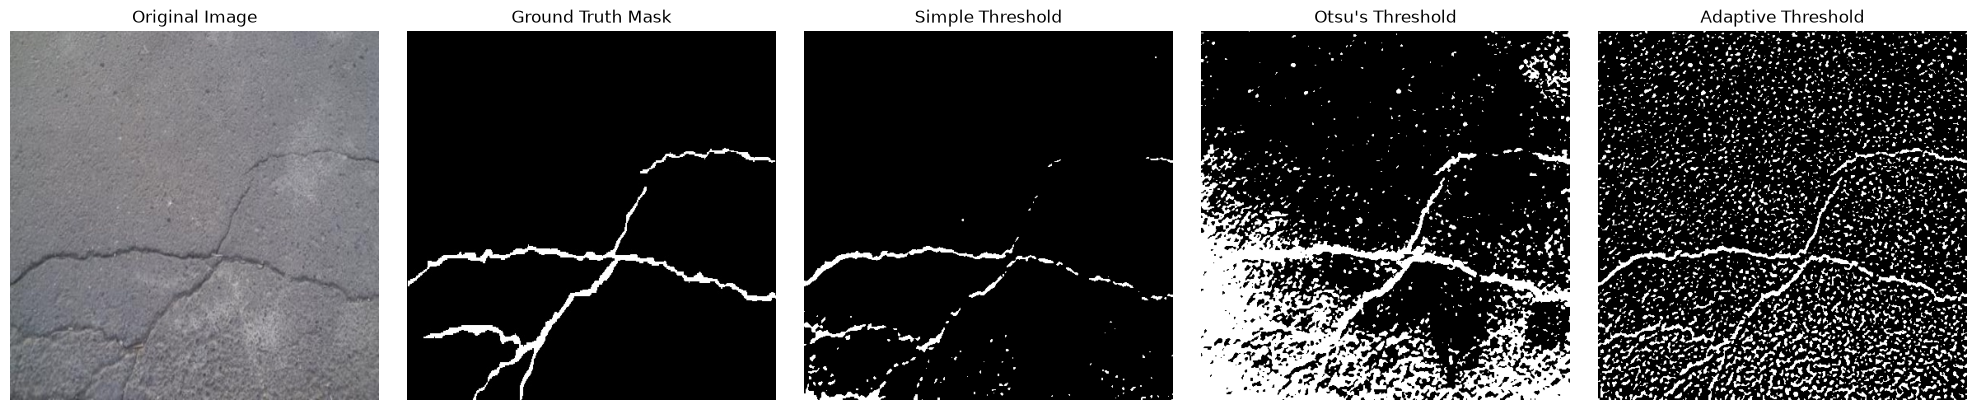

In [8]:
# 1. Load single sample pair
sample_img_path = image_files_list[0]['path'] if isinstance(image_files_list[0], dict) else image_files_list[0]
sample_mask_path = mask_files_list[0]['path'] if isinstance(mask_files_list[0], dict) else mask_files_list[0]

img_bgr = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
ground_truth = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# 2. Pre-processing: Convert to Grayscale & Apply Gaussian Blur
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Method A: Simple Inverse Threshold (Manual Cutoff)
# Pixels darker than 100 become white (255)
_, simple_thresh = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY_INV)

# Method B: Otsu's Thresholding (Automatic global threshold search)
_, otsu_thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Method C: Adaptive Thresholding (Handles uneven lighting across the road)
adaptive_thresh = cv2.adaptiveThreshold(
    blurred, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 
    blockSize=15, # Local pixel neighborhood size
    C=4           # Subtracted constant
)

# 3. Plot and Compare Results
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(ground_truth, cmap="gray")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

axes[2].imshow(simple_thresh, cmap="gray")
axes[2].set_title("Simple Threshold")
axes[2].axis("off")

axes[3].imshow(otsu_thresh, cmap="gray")
axes[3].set_title("Otsu's Threshold")
axes[3].axis("off")

axes[4].imshow(adaptive_thresh, cmap="gray")
axes[4].set_title("Adaptive Threshold")
axes[4].axis("off")

plt.tight_layout()
plt.show()

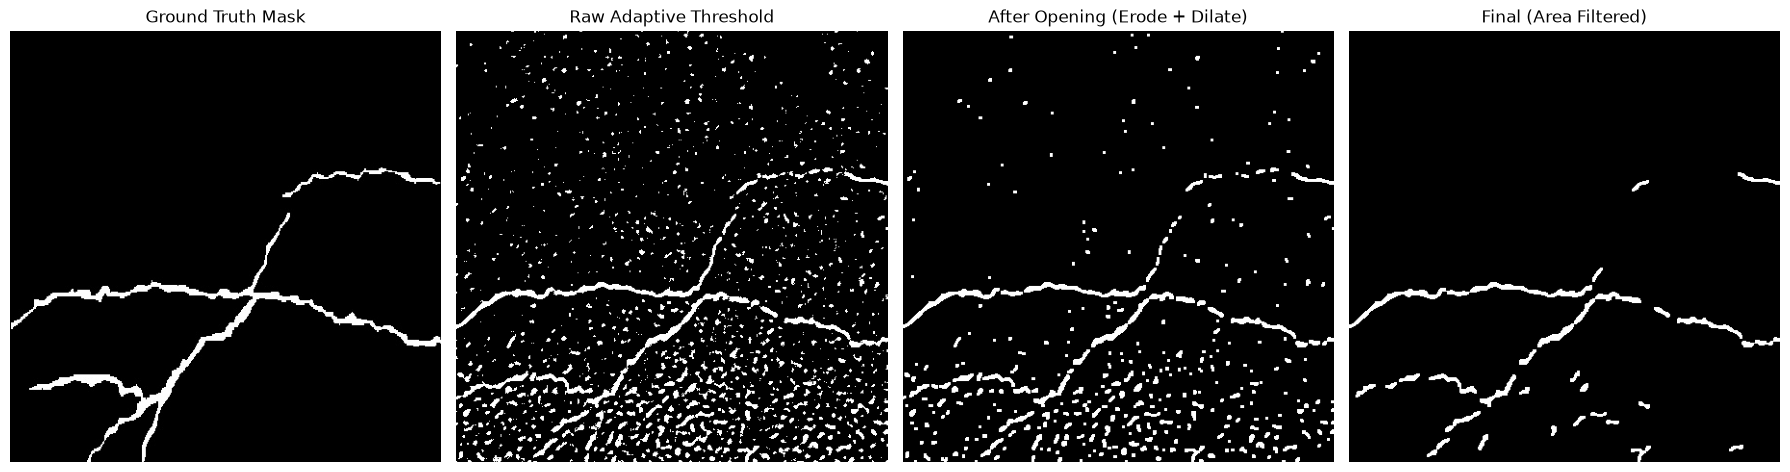

In [9]:
# 1. Load image and apply pre-processing
sample_img_path = image_files_list[0]['path'] if isinstance(image_files_list[0], dict) else image_files_list[0]
img_bgr = cv2.imread(sample_img_path)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Apply a strong blur (e.g., 7x7 or Median Blur) to suppress asphalt grain before thresholding
blurred = cv2.medianBlur(gray, 5)

# 2. Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(
    blurred, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 
    blockSize=19, # Increased neighborhood size reduces speckle noise
    C=5           # Increasing C constant makes threshold stricter
)

# 3. Morphological Opening (Remove small white noise)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
opened = cv2.morphologyEx(adaptive_thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# 4. Contour Area Filtering (Remove remaining isolated white blobs)
# Find all white blobs
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opened)

# Create an empty black mask
cleaned_mask = np.zeros_like(opened)

# Minimum pixel area to keep (adjust based on resolution)
min_area = 50  

# Loop over all detected components (index 0 is background)
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= min_area:
        cleaned_mask[labels == i] = 255

# 5. Optional Morphological Closing (Bridge broken crack lines)
closing_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
final_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, closing_kernel)

# Display comparisons
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(ground_truth, cmap="gray")
axes[0].set_title("Ground Truth Mask")
axes[0].axis("off")

axes[1].imshow(adaptive_thresh, cmap="gray")
axes[1].set_title("Raw Adaptive Threshold")
axes[1].axis("off")

axes[2].imshow(opened, cmap="gray")
axes[2].set_title("After Opening (Erode + Dilate)")
axes[2].axis("off")

axes[3].imshow(final_mask, cmap="gray")
axes[3].set_title("Final (Area Filtered)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

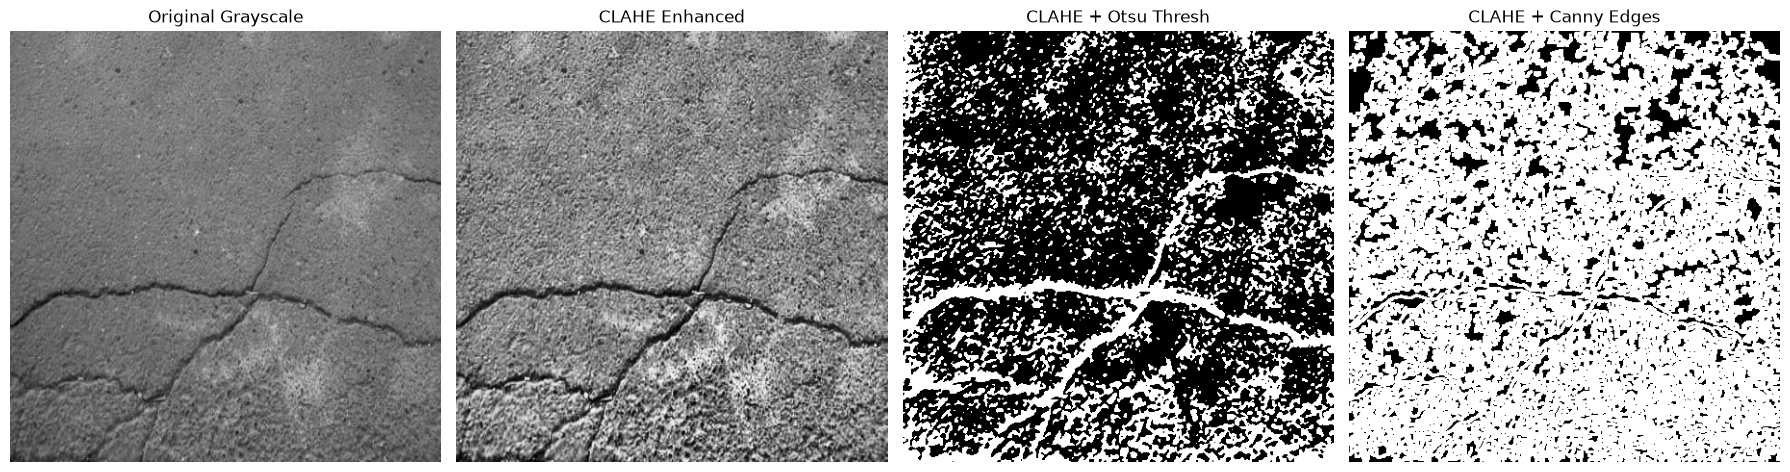

In [10]:
# 1. Load image in grayscale
sample_img_path = image_files_list[0]['path'] if isinstance(image_files_list[0], dict) else image_files_list[0]
gray = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)

# 2. Step 1: Contrast Enhancement via CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced_gray = clahe.apply(gray)

# 3. Step 2: Smoothing to eliminate fine asphalt grain
blurred = cv2.GaussianBlur(enhanced_gray, (5, 5), 0)

# 4. Pipeline A: CLAHE + Otsu Thresholding
_, clahe_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 5. Pipeline B: CLAHE + Canny Edge Detection
# Thresholds (50, 150) capture faint edges while suppressing weak noise
canny_edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

# Optional: Dilate Canny edges to fill small gaps along crack lines
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
dilated_edges = cv2.dilate(canny_edges, kernel, iterations=1)

# Display comparisons
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

axes[1].imshow(enhanced_gray, cmap="gray")
axes[1].set_title("CLAHE Enhanced")
axes[1].axis("off")

axes[2].imshow(clahe_otsu, cmap="gray")
axes[2].set_title("CLAHE + Otsu Thresh")
axes[2].axis("off")

axes[3].imshow(dilated_edges, cmap="gray")
axes[3].set_title("CLAHE + Canny Edges")
axes[3].axis("off")

plt.tight_layout()
plt.show()

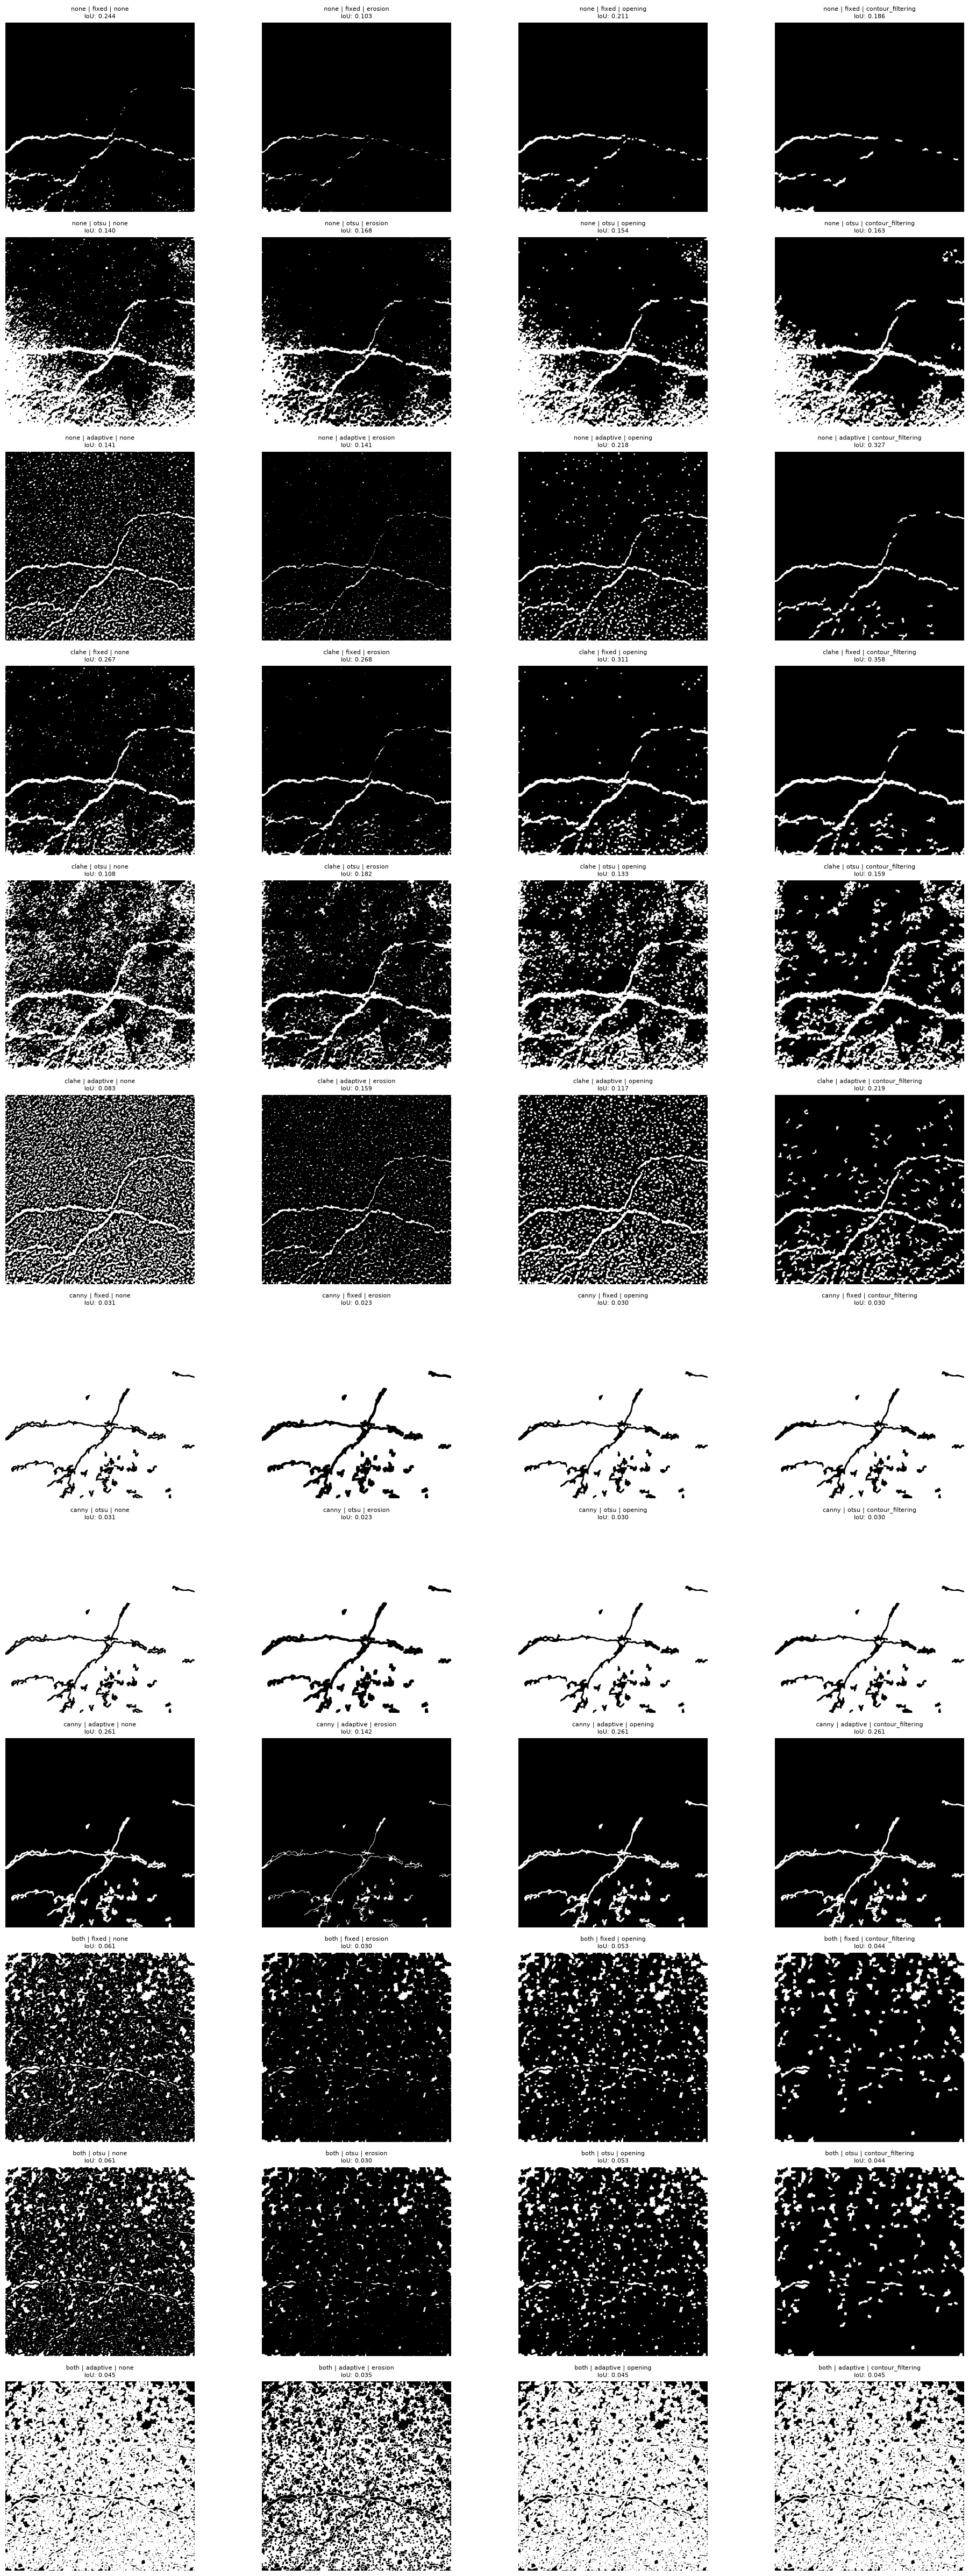

--- BEST CONFIGURATION ---
Pre-processing : clahe
Thresholding   : fixed
Post-processing : contour_filtering
Best IoU Score  : 0.3581


In [11]:

# ---------------------------------------------------------
# 1. Pipeline Modular Functions
# ---------------------------------------------------------

def apply_preprocessing(gray, method):
    """
    Pre-processing methods: 'none', 'clahe', 'canny', 'both'
    """
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    if method == 'none':
        return blurred
    
    elif method == 'clahe':
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        return clahe.apply(blurred)
    
    elif method == 'canny':
        edges = cv2.Canny(blurred, 50, 150)
        # Dilate to create solid structural edges
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        return cv2.dilate(edges, kernel, iterations=1)
    
    elif method == 'both':
        # CLAHE followed by Canny Edge Detection
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(blurred)
        edges = cv2.Canny(enhanced, 50, 150)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        return cv2.dilate(edges, kernel, iterations=1)

def apply_thresholding(img_prep, method):
    """
    Thresholding methods: 'fixed', 'otsu', 'adaptive'
    """
    if method == 'fixed':
        _, thresh = cv2.threshold(img_prep, 100, 255, cv2.THRESH_BINARY_INV)
        return thresh
    
    elif method == 'otsu':
        _, thresh = cv2.threshold(img_prep, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return thresh
    
    elif method == 'adaptive':
        # If input is already binary (e.g. Canny output), return as-is
        if len(np.unique(img_prep)) <= 2 and img_prep.max() == 255:
            return img_prep
        return cv2.adaptiveThreshold(
            img_prep, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, blockSize=19, C=5
        )

def apply_postprocessing(binary_mask, method):
    """
    Post-processing methods: 'none', 'erosion', 'opening', 'contour_filtering'
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    
    if method == 'none':
        return binary_mask
    
    elif method == 'erosion':
        return cv2.erode(binary_mask, kernel, iterations=1)
    
    elif method == 'opening':
        return cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    
    elif method == 'contour_filtering':
        # First do a soft opening to decouple noise
        opened = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(opened)
        cleaned = np.zeros_like(opened)
        min_area = 40  # Minimum pixel threshold for crack components
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= min_area:
                cleaned[labels == i] = 255
        return cleaned

def calculate_iou(pred_mask, gt_mask):
    """
    Calculates Intersection over Union (IoU) accuracy metric.
    """
    intersection = np.logical_and(pred_mask > 0, gt_mask > 0).sum()
    union = np.logical_or(pred_mask > 0, gt_mask > 0).sum()
    if union == 0:
        return 0.0
    return intersection / union

# ---------------------------------------------------------
# 2. Execution & Grid Plotting
# ---------------------------------------------------------

# Sample paths setup
sample_img_path = image_files_list[0]['path'] if isinstance(image_files_list[0], dict) else image_files_list[0]
sample_mask_path = mask_files_list[0]['path'] if isinstance(mask_files_list[0], dict) else mask_files_list[0]

gray_img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# Configurations setup
preprocess_methods = ['none', 'clahe', 'canny', 'both']
thresh_methods = ['fixed', 'otsu', 'adaptive']
postprocess_methods = ['none', 'erosion', 'opening', 'contour_filtering']

# Generate 48 unique pipeline combinations
all_combinations = list(itertools.product(preprocess_methods, thresh_methods, postprocess_methods))

# Setup 12x4 Grid plot
fig, axes = plt.subplots(12, 4, figsize=(20, 48))
axes = axes.flatten()

best_iou = -1.0
best_config = None

for idx, (prep, thresh, post) in enumerate(all_combinations):
    # Execute Pipeline
    step1 = apply_preprocessing(gray_img, prep)
    step2 = apply_thresholding(step1, thresh)
    final_result = apply_postprocessing(step2, post)
    
    # Calculate performance relative to ground truth
    score = calculate_iou(final_result, gt_mask)
    
    if score > best_iou:
        best_iou = score
        best_config = (prep, thresh, post)
    
    # Plotting cell
    axes[idx].imshow(final_result, cmap='gray')
    axes[idx].set_title(f"{prep} | {thresh} | {post}\nIoU: {score:.3f}", fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"--- BEST CONFIGURATION ---")
print(f"Pre-processing : {best_config[0]}")
print(f"Thresholding   : {best_config[1]}")
print(f"Post-processing : {best_config[2]}")
print(f"Best IoU Score  : {best_iou:.4f}")

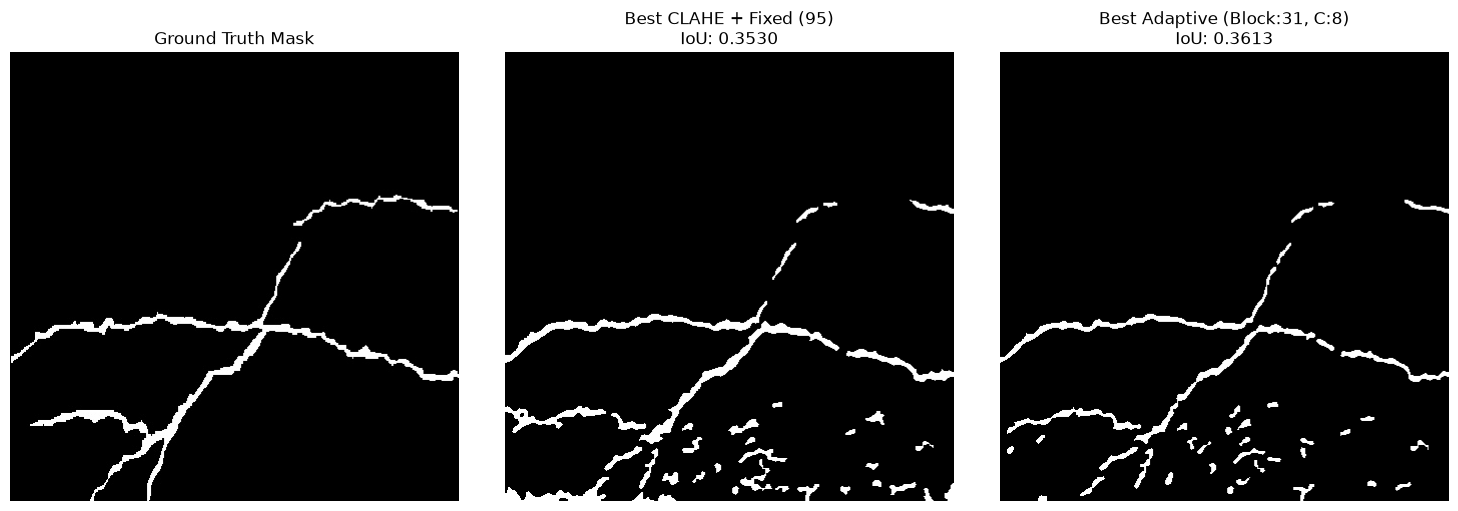

Optimal Fixed Cutoff Value: 95 -> Peak IoU: 0.3530
Optimal Adaptive Settings : BlockSize=31, C=8 -> Peak IoU: 0.3613


In [12]:
# Load sample images
sample_img_path = image_files_list[0]['path'] if isinstance(image_files_list[0], dict) else image_files_list[0]
sample_mask_path = mask_files_list[0]['path'] if isinstance(mask_files_list[0], dict) else mask_files_list[0]

gray = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

def calculate_iou(pred, gt):
    intersection = np.logical_and(pred > 0, gt > 0).sum()
    union = np.logical_or(pred > 0, gt > 0).sum()
    return intersection / union if union > 0 else 0.0

def filter_contours(binary_mask, min_area=30):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask)
    cleaned = np.zeros_like(binary_mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == i] = 255
    return cleaned

# Prepare smoothed inputs
median_blur = cv2.medianBlur(gray, 5)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
clahe_enhanced = clahe.apply(median_blur)

# ---------------------------------------------------------
# 1. Sweep Fixed Thresholds (CLAHE + Fixed + Filter)
# ---------------------------------------------------------
best_fixed_iou = 0.0
best_thresh_val = None
best_fixed_mask = None

for thresh_val in range(60, 150, 5):
    _, binarized = cv2.threshold(clahe_enhanced, thresh_val, 255, cv2.THRESH_BINARY_INV)
    cleaned = filter_contours(binarized, min_area=40)
    
    # Bridge small gaps along cracks
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    
    score = calculate_iou(closed, gt_mask)
    if score > best_fixed_iou:
        best_fixed_iou = score
        best_thresh_val = thresh_val
        best_fixed_mask = closed

# ---------------------------------------------------------
# 2. Sweep Adaptive Parameters (Median + Adaptive + Filter)
# ---------------------------------------------------------
best_adaptive_iou = 0.0
best_adaptive_params = None
best_adaptive_mask = None

for block_size in [15, 19, 25, 31]:
    for C_val in [2, 4, 6, 8, 10]:
        adaptive_raw = cv2.adaptiveThreshold(
            median_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, block_size, C_val
        )
        cleaned = filter_contours(adaptive_raw, min_area=40)
        
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        closed = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
        
        score = calculate_iou(closed, gt_mask)
        if score > best_adaptive_iou:
            best_adaptive_iou = score
            best_adaptive_params = (block_size, C_val)
            best_adaptive_mask = closed

# ---------------------------------------------------------
# 3. Plot Best Optimized Results
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gt_mask, cmap='gray')
axes[0].set_title("Ground Truth Mask")
axes[0].axis('off')

axes[1].imshow(best_fixed_mask, cmap='gray')
axes[1].set_title(f"Best CLAHE + Fixed ({best_thresh_val})\nIoU: {best_fixed_iou:.4f}")
axes[1].axis('off')

axes[2].imshow(best_adaptive_mask, cmap='gray')
axes[2].set_title(f"Best Adaptive (Block:{best_adaptive_params[0]}, C:{best_adaptive_params[1]})\nIoU: {best_adaptive_iou:.4f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Optimal Fixed Cutoff Value: {best_thresh_val} -> Peak IoU: {best_fixed_iou:.4f}")
print(f"Optimal Adaptive Settings : BlockSize={best_adaptive_params[0]}, C={best_adaptive_params[1]} -> Peak IoU: {best_adaptive_iou:.4f}")

In [13]:
def filter_wear_artifacts(binary_mask, min_area=30, min_aspect_ratio=2.5, max_solidity=0.7):
    """
    Filters out round/blocky wear marks while keeping long thin crack segments.
    """
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cleaned_mask = np.zeros_like(binary_mask)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        
        # 1. Calculate Bounding Rectangle Aspect Ratio
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(max(w, h)) / min(w, h)
        
        # 2. Calculate Solidity (Area / Area of Convex Hull)
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0
        
        # Filter: Keep if it's elongated OR if it has low solidity (winding/thin)
        # Large continuous crack structures might have high area, so keep large components regardless
        if (aspect_ratio >= min_aspect_ratio) or (solidity <= max_solidity) or (area > 500):
            cv2.drawContours(cleaned_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    return cleaned_mask

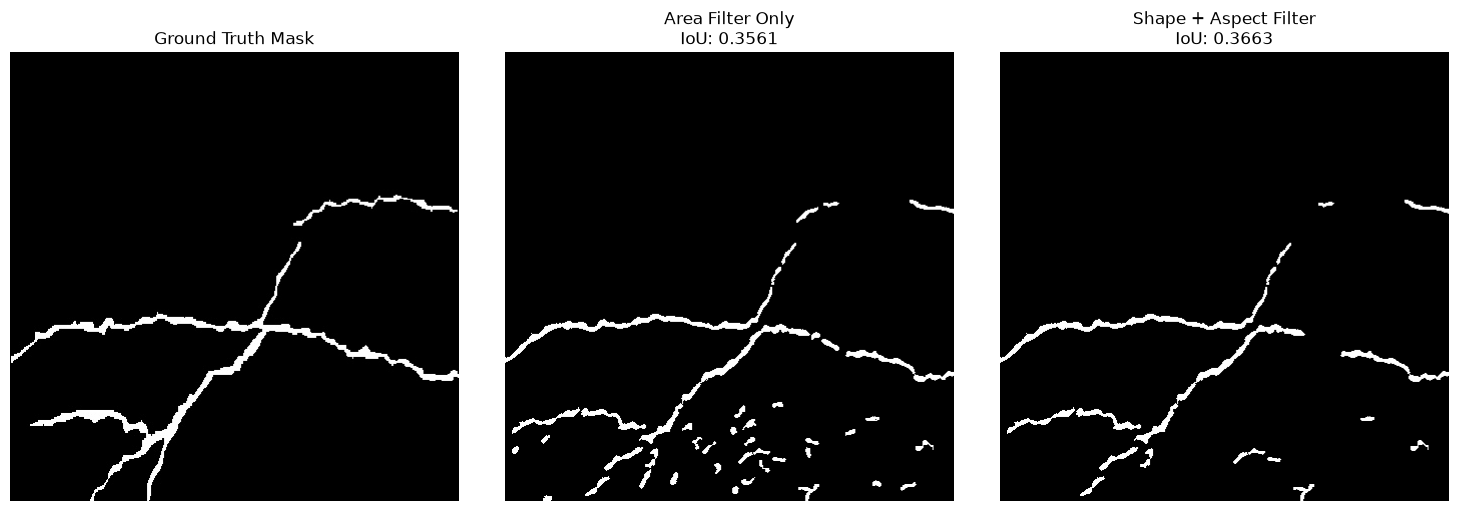

Area Filter IoU : 0.3561
Shape Filter IoU: 0.3663


In [14]:
# 1. Load inputs
gray = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# 2. Run your winning Adaptive setup
median_blur = cv2.medianBlur(gray, 5)
adaptive_raw = cv2.adaptiveThreshold(
    median_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, blockSize=31, C=8
)

# 3. Compare standard area filter vs. Shape/Geometry Filter
standard_filtered = filter_contours(adaptive_raw, min_area=40)
shape_filtered = filter_wear_artifacts(adaptive_raw, min_area=30, min_aspect_ratio=2.2, max_solidity=0.65)

# Calculate IoUs
iou_standard = calculate_iou(standard_filtered, gt_mask)
iou_shape = calculate_iou(shape_filtered, gt_mask)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gt_mask, cmap='gray')
axes[0].set_title("Ground Truth Mask")
axes[0].axis('off')

axes[1].imshow(standard_filtered, cmap='gray')
axes[1].set_title(f"Area Filter Only\nIoU: {iou_standard:.4f}")
axes[1].axis('off')

axes[2].imshow(shape_filtered, cmap='gray')
axes[2].set_title(f"Shape + Aspect Filter\nIoU: {iou_shape:.4f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Area Filter IoU : {iou_standard:.4f}")
print(f"Shape Filter IoU: {iou_shape:.4f}")

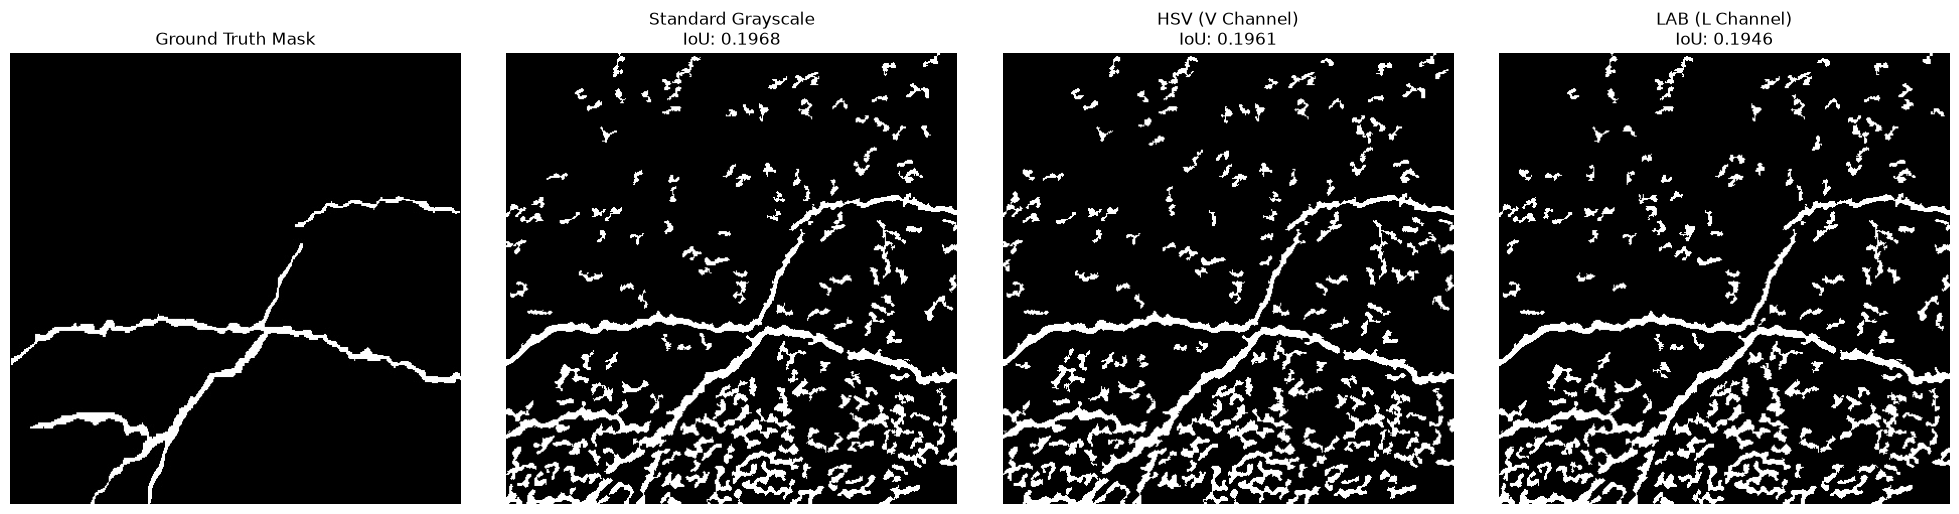

Grayscale IoU   : 0.1968
HSV V-Channel IoU: 0.1961
LAB L-Channel IoU: 0.1946


In [15]:
# 1. Load BGR Image
sample_img_path = image_files_list[0]['path'] if isinstance(image_files_list[0], dict) else image_files_list[0]
sample_mask_path = mask_files_list[0]['path'] if isinstance(mask_files_list[0], dict) else mask_files_list[0]

img_bgr = cv2.imread(sample_img_path)
gt_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# 2. Extract Channels
# Channel A: Standard Grayscale
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Channel B: HSV -> Value (V) Channel
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
v_channel = hsv[:, :, 2]

# Channel C: LAB -> Lightness (L) Channel
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
l_channel = lab[:, :, 0]

# 3. Process Each Channel Through Your Pipeline
def evaluate_channel(channel_img, name):
    # Apply Median Blur + CLAHE
    blurred = cv2.medianBlur(channel_img, 5)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    
    # Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(
        enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, blockSize=31, C=8
    )
    
    # Post-Processing: Geometric Wear Filter
    final_mask = filter_wear_artifacts(thresh, min_area=30, min_aspect_ratio=2.2, max_solidity=0.65)
    
    # Compute IoU
    score = calculate_iou(final_mask, gt_mask)
    return final_mask, score

mask_gray, iou_gray = evaluate_channel(gray, "Grayscale")
mask_v, iou_v = evaluate_channel(v_channel, "HSV Value")
mask_l, iou_l = evaluate_channel(l_channel, "LAB Lightness")

# 4. Display Comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(gt_mask, cmap='gray')
axes[0].set_title("Ground Truth Mask")
axes[0].axis('off')

axes[1].imshow(mask_gray, cmap='gray')
axes[1].set_title(f"Standard Grayscale\nIoU: {iou_gray:.4f}")
axes[1].axis('off')

axes[2].imshow(mask_v, cmap='gray')
axes[2].set_title(f"HSV (V Channel)\nIoU: {iou_v:.4f}")
axes[2].axis('off')

axes[3].imshow(mask_l, cmap='gray')
axes[3].set_title(f"LAB (L Channel)\nIoU: {iou_l:.4f}")
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"Grayscale IoU   : {iou_gray:.4f}")
print(f"HSV V-Channel IoU: {iou_v:.4f}")
print(f"LAB L-Channel IoU: {iou_l:.4f}")

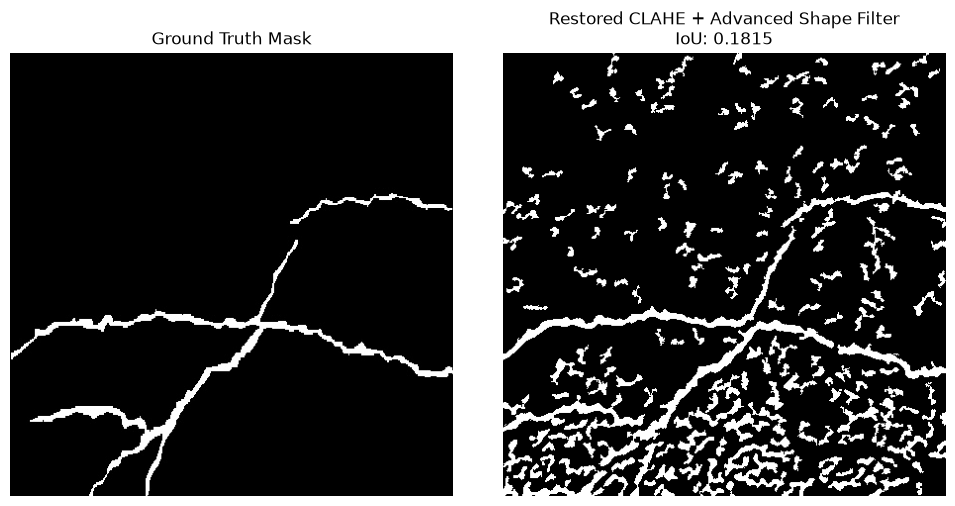

Restored Pipeline IoU: 0.1815


In [16]:
# 1. Load inputs
gray = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# 2. Complete Pre-processing (Median Blur + CLAHE)
median_blur = cv2.medianBlur(gray, 5)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
clahe_enhanced = clahe.apply(median_blur) # <--- Re-inserted CLAHE

# 3. Adaptive Thresholding
adaptive_raw = cv2.adaptiveThreshold(
    clahe_enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, blockSize=31, C=8
)

# 4. Improved Wear Artifact Filtering (Perimeter-to-Area Ratio)
def filter_wear_advanced(binary_mask, min_area=30, max_solidity=0.75):
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cleaned_mask = np.zeros_like(binary_mask)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
            
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue

        # Thin winding cracks have extremely high perimeter relative to area
        # Round/square wear marks have low perimeter relative to area
        circularity = (4 * np.pi * area) / (perimeter ** 2) # 1.0 for perfect circle, near 0.0 for long thin cracks

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0

        # Keep if it is thin/jagged (low circularity) OR low solidity OR large component
        if (circularity < 0.4) or (solidity < max_solidity) or (area > 300):
            cv2.drawContours(cleaned_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    return cleaned_mask

# Execute
shape_filtered = filter_wear_advanced(adaptive_raw)

# Calculate IoU
def calculate_iou(pred, gt):
    intersection = np.logical_and(pred > 0, gt > 0).sum()
    union = np.logical_or(pred > 0, gt > 0).sum()
    return intersection / union if union > 0 else 0.0

iou_score = calculate_iou(shape_filtered, gt_mask)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gt_mask, cmap='gray')
axes[0].set_title("Ground Truth Mask")
axes[0].axis('off')

axes[1].imshow(shape_filtered, cmap='gray')
axes[1].set_title(f"Restored CLAHE + Advanced Shape Filter\nIoU: {iou_score:.4f}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Restored Pipeline IoU: {iou_score:.4f}")

In [17]:
# Dictionary to systematically store and track experiment history
experiment_log = {}

def binarize_gt_mask(mask_path):
    """
    Loads ground truth mask in grayscale and applies a sharp binary threshold
    at 127 to remove lossy JPEG compression artifacts (values 1–20).
    """
    gt_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if gt_raw is None:
        raise ValueError(f"Could not load mask from path: {mask_path}")
    # Strict binarization to eliminate edge compression noise
    _, gt_bin = cv2.threshold(gt_raw, 127, 255, cv2.THRESH_BINARY)
    return gt_bin

def calculate_iou(pred_mask, gt_bin):
    """
    Calculates Intersection over Union (IoU) between prediction and ground truth.
    """
    pred_bin = (pred_mask > 0).astype(np.uint8)
    gt_bin_bool = (gt_bin > 0).astype(np.uint8)
    
    intersection = np.logical_and(pred_bin, gt_bin_bool).sum()
    union = np.logical_or(pred_bin, gt_bin_bool).sum()
    
    if union == 0:
        return 0.0
    return float(intersection / union)

def log_experiment(step_name, params, iou_score):
    """
    Logs experiment configuration and score.
    """
    experiment_log[step_name] = {
        "params": params,
        "iou": iou_score
    }
    print(f"========== LOGGED [{step_name}] ==========")
    print(f"Parameters : {params}")
    print(f"Clean IoU  : {iou_score:.4f}")
    print("=" * 42 + "\n")

# Load sample image and clean GT mask once for all tests
sample_img_path = image_files_list[0]['path'] if isinstance(image_files_list[0], dict) else image_files_list[0]
sample_mask_path = mask_files_list[0]['path'] if isinstance(mask_files_list[0], dict) else mask_files_list[0]

sample_gray = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
sample_gt_clean = binarize_gt_mask(sample_mask_path)

print("Step 1 Complete: GT mask binarization and experiment logger ready.")

Step 1 Complete: GT mask binarization and experiment logger ready.


In [18]:
def filter_wear_artifacts(binary_img):
    """
    Filters out wear and shadow artifacts using geometric properties:
    aspect ratio, solidity, and area.
    """
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered_mask = np.zeros_like(binary_img)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area == 0:
            continue
            
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(max(w, h)) / min(w, h) if min(w, h) > 0 else 0
        
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0
        
        # Keep contours matching the winning filter criteria
        if (aspect_ratio >= 2.2) or (solidity <= 0.65) or (area > 500):
            cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)
            
    return filtered_mask

# --- Step 2 Pipeline Execution ---
# 1. Preprocessing
median_blur = cv2.medianBlur(sample_gray, 5)

# 2. Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(
    median_blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    blockSize=31,
    C=8
)

# 3. Artifact Filtering
step2_pred_mask = filter_wear_artifacts(adaptive_thresh)

# 4. Evaluation against cleaned JPEG ground truth
step2_iou = calculate_iou(step2_pred_mask, sample_gt_clean)

# 5. Log Results
params_step2 = {
    "preprocessing": "medianBlur(5)",
    "threshold": "adaptiveThreshold(GAUSSIAN, block=31, C=8)",
    "filter": "filter_wear_artifacts(aspect>=2.2 or solidity<=0.65 or area>500)"
}
log_experiment("Step 2 - Baseline Restoration", params_step2, step2_iou)

========== LOGGED [Step 2 - Baseline Restoration] ==========
Parameters : {'preprocessing': 'medianBlur(5)', 'threshold': 'adaptiveThreshold(GAUSSIAN, block=31, C=8)', 'filter': 'filter_wear_artifacts(aspect>=2.2 or solidity<=0.65 or area>500)'}
Clean IoU  : 0.4669



Running Grid Search across 225 CLAHE + Adaptive parameter combinations...

========== LOGGED [Step 3 - Re-tuned CLAHE Grid Search] ==========
Parameters : {'preprocessing': 'medianBlur(5) + CLAHE(clipLimit=1.0, tileGridSize=(4, 4))', 'threshold': 'adaptiveThreshold(GAUSSIAN, block=41, C=15)', 'filter': 'filter_wear_artifacts(aspect>=2.2 or solidity<=0.65 or area>500)', 'baseline_iou': 0.4669, 'delta': 0.031162698133145483}
Clean IoU  : 0.4981



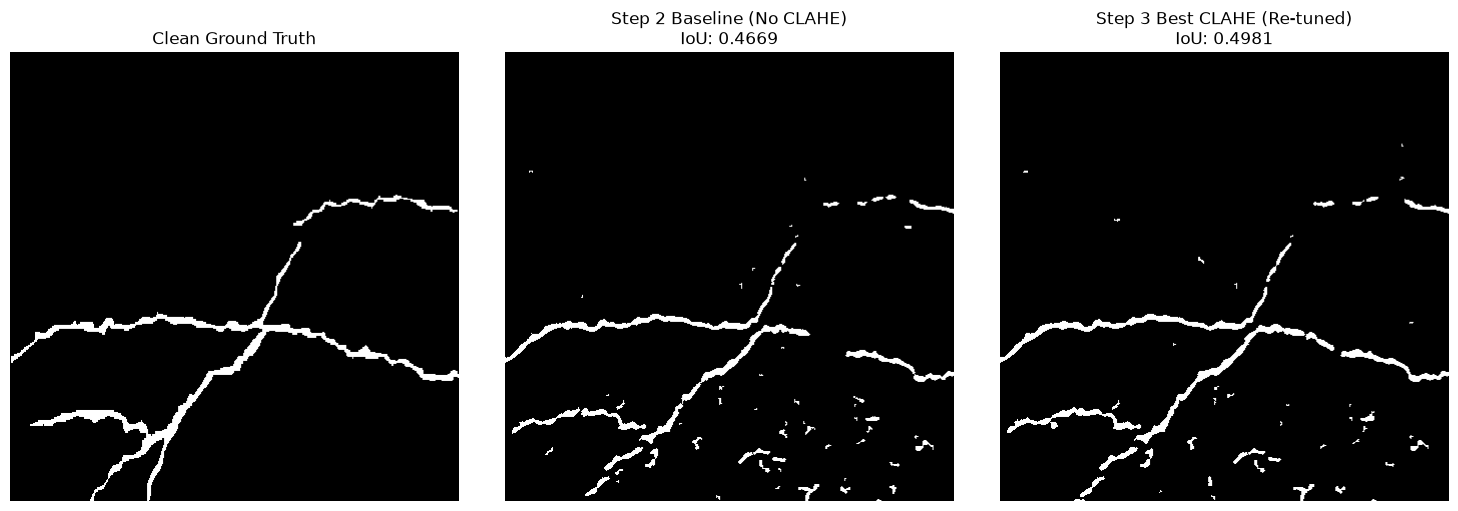

In [19]:
# 1. Parameter Grid
clip_limits = [1.0, 2.0, 3.0]
tile_grid_sizes = [(4, 4), (8, 8), (16, 16)]
block_sizes = [15, 21, 31, 41, 51]
c_values = [2, 5, 8, 12, 15]

# Pre-smooth image using median blur
median_blur = cv2.medianBlur(sample_gray, 5)

best_clahe_iou = 0.0
best_clahe_params = {}
best_clahe_pred = None

# Total iterations: 3 * 3 * 5 * 5 = 225 combinations
total_combinations = len(clip_limits) * len(tile_grid_sizes) * len(block_sizes) * len(c_values)
print(f"Running Grid Search across {total_combinations} CLAHE + Adaptive parameter combinations...\n")

for clip, tile, block, c_val in itertools.product(clip_limits, tile_grid_sizes, block_sizes, c_values):
    # A. Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    clahe_enhanced = clahe.apply(median_blur)
    
    # B. Adaptive Threshold on CLAHE image
    adaptive_thresh = cv2.adaptiveThreshold(
        clahe_enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=block,
        C=c_val
    )
    
    # C. Keep shape filter constant
    pred_mask = filter_wear_artifacts(adaptive_thresh)
    
    # D. Compute IoU
    iou = calculate_iou(pred_mask, sample_gt_clean)
    
    if iou > best_clahe_iou:
        best_clahe_iou = iou
        best_clahe_params = {
            "clipLimit": clip,
            "tileGridSize": tile,
            "blockSize": block,
            "C": c_val
        }
        best_clahe_pred = pred_mask

# 2. Log Results
params_step3 = {
    "preprocessing": f"medianBlur(5) + CLAHE(clipLimit={best_clahe_params['clipLimit']}, tileGridSize={best_clahe_params['tileGridSize']})",
    "threshold": f"adaptiveThreshold(GAUSSIAN, block={best_clahe_params['blockSize']}, C={best_clahe_params['C']})",
    "filter": "filter_wear_artifacts(aspect>=2.2 or solidity<=0.65 or area>500)",
    "baseline_iou": 0.4669,
    "delta": float(best_clahe_iou - 0.4669)
}

log_experiment("Step 3 - Re-tuned CLAHE Grid Search", params_step3, best_clahe_iou)

# 3. Plot Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_gt_clean, cmap="gray")
axes[0].set_title("Clean Ground Truth")
axes[0].axis("off")

axes[1].imshow(step2_pred_mask, cmap="gray")
axes[1].set_title(f"Step 2 Baseline (No CLAHE)\nIoU: 0.4669")
axes[1].axis("off")

axes[2].imshow(best_clahe_pred, cmap="gray")
axes[2].set_title(f"Step 3 Best CLAHE (Re-tuned)\nIoU: {best_clahe_iou:.4f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [20]:
def filter_wear_advanced(binary_img, circ_thresh=0.4, sol_thresh=0.75, min_area=300):
    """
    Advanced filter using circularity (4 * pi * area / perimeter^2) and solidity
    to isolate linear, complex crack features from rounded/blocky wear marks.
    """
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered_mask = np.zeros_like(binary_img)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
            
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
            
        circularity = (4.0 * np.pi * area) / (perimeter ** 2)
        
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0
        
        # Keep contours with low circularity (elongated) OR low solidity (curved/branched)
        if (circularity < circ_thresh) or (solidity < sol_thresh):
            cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)
            
    return filtered_mask


# --- 1. Prepare Base Binarized Maps ---
# Pipeline A: With CLAHE (best params from Step 3)
clahe_opt = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(4, 4))
img_clahe = clahe_opt.apply(median_blur)
thresh_with_clahe = cv2.adaptiveThreshold(
    img_clahe, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 41, 15
)

# Pipeline B: Without CLAHE (best params from Step 2)
thresh_no_clahe = cv2.adaptiveThreshold(
    median_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 8
)


# --- 2. Evaluate Combinations ---
results_step4 = {
    "CLAHE + filter_wear_artifacts": calculate_iou(
        filter_wear_artifacts(thresh_with_clahe), sample_gt_clean
    ),
    "CLAHE + filter_wear_advanced": calculate_iou(
        filter_wear_advanced(thresh_with_clahe), sample_gt_clean
    ),
    "No-CLAHE + filter_wear_artifacts": calculate_iou(
        filter_wear_artifacts(thresh_no_clahe), sample_gt_clean
    ),
    "No-CLAHE + filter_wear_advanced": calculate_iou(
        filter_wear_advanced(thresh_no_clahe), sample_gt_clean
    ),
}

# --- 3. Log Results ---
print("========== STEP 4 EXPERIMENTAL RESULTS ==========")
for config, score in results_step4.items():
    print(f"Config: {config:<35} | IoU: {score:.4f}")
print("=================================================\n")

log_experiment("Step 4 - Filter Comparison Across Pipelines", results_step4, max(results_step4.values()))

========== STEP 4 EXPERIMENTAL RESULTS ==========
Config: CLAHE + filter_wear_artifacts       | IoU: 0.4981
Config: CLAHE + filter_wear_advanced        | IoU: 0.4787
Config: No-CLAHE + filter_wear_artifacts    | IoU: 0.4669
Config: No-CLAHE + filter_wear_advanced     | IoU: 0.4070

========== LOGGED [Step 4 - Filter Comparison Across Pipelines] ==========
Parameters : {'CLAHE + filter_wear_artifacts': 0.49806269813314547, 'CLAHE + filter_wear_advanced': 0.47872485976193735, 'No-CLAHE + filter_wear_artifacts': 0.466927453769559, 'No-CLAHE + filter_wear_advanced': 0.40702508960573475}
Clean IoU  : 0.4981



========== STEP 5 COLOR CHANNEL RESULTS ==========
Channel: Grayscale            | IoU: 0.4981
Channel: HSV (V-Channel)      | IoU: 0.4872
Channel: LAB (L-Channel)      | IoU: 0.4911

========== LOGGED [Step 5 - Color Channel Comparison] ==========
Parameters : {'Grayscale': 0.49806269813314547, 'HSV (V-Channel)': 0.48717948717948717, 'LAB (L-Channel)': 0.49114838108548803}
Clean IoU  : 0.4981



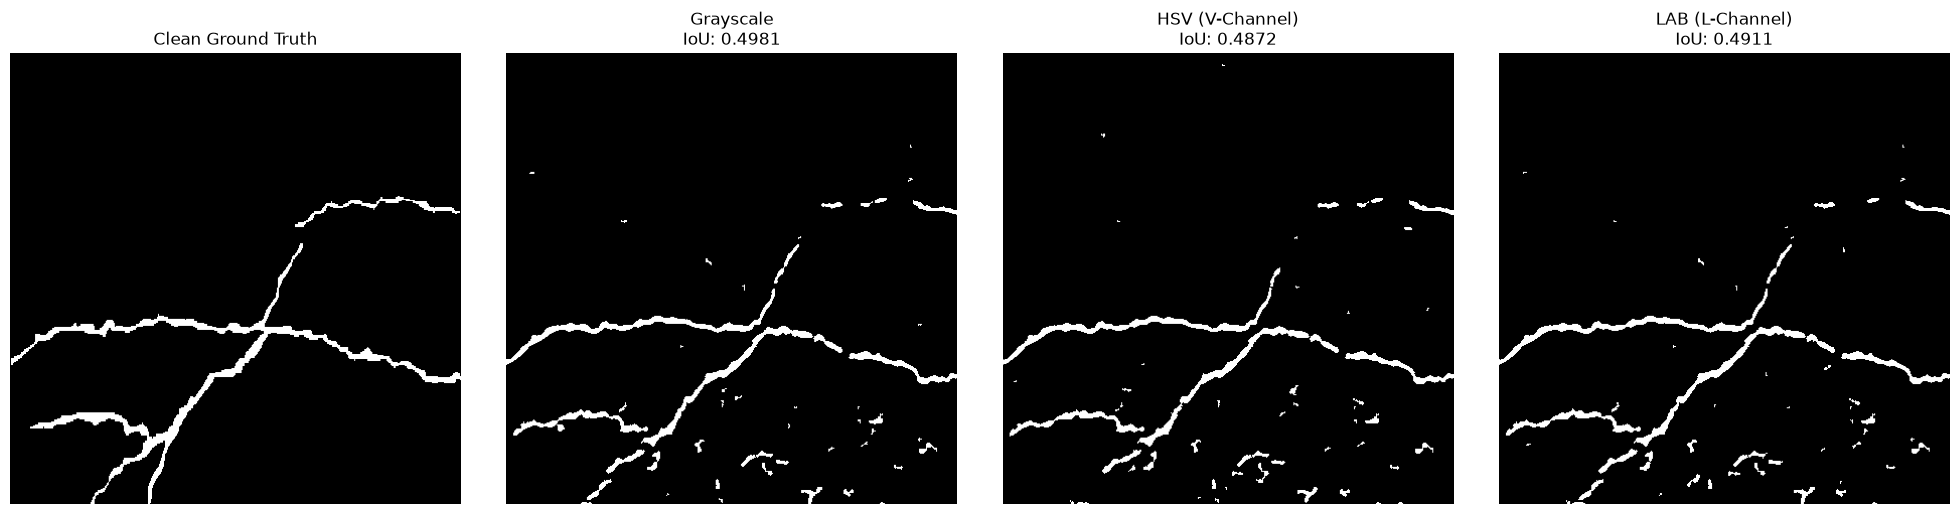

In [21]:
# --- Load Original BGR Image ---
img_bgr = cv2.imread(sample_img_path)
if img_bgr is None:
    raise ValueError(f"Could not load BGR image from: {sample_img_path}")

# --- 1. Extract Individual Channels ---
# Channel A: Grayscale
channel_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Channel B: HSV -> V (Value) Channel
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
channel_hsv_v = hsv[:, :, 2]

# Channel C: CIELAB -> L (Lightness) Channel
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
channel_lab_l = lab[:, :, 0]

# --- 2. Helper Pipeline Execution Function ---
def run_winning_pipeline(channel_image):
    """
    Applies the exact Step 4 winning configuration on an input single-channel image.
    """
    # Preprocessing
    blurred = cv2.medianBlur(channel_image, 5)
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(blurred)
    
    # Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=41,
        C=15
    )
    
    # Shape/Wear Artifact Filtering
    pred_mask = filter_wear_artifacts(thresh)
    return pred_mask

# --- 3. Execute Across All Channels ---
pred_gray = run_winning_pipeline(channel_gray)
pred_hsv_v = run_winning_pipeline(channel_hsv_v)
pred_lab_l = run_winning_pipeline(channel_lab_l)

# --- 4. Calculate IoU Metrics ---
iou_gray = calculate_iou(pred_gray, sample_gt_clean)
iou_hsv_v = calculate_iou(pred_hsv_v, sample_gt_clean)
iou_lab_l = calculate_iou(pred_lab_l, sample_gt_clean)

# --- 5. Log Results ---
results_step5 = {
    "Grayscale": iou_gray,
    "HSV (V-Channel)": iou_hsv_v,
    "LAB (L-Channel)": iou_lab_l
}

print("========== STEP 5 COLOR CHANNEL RESULTS ==========")
for channel_name, score in results_step5.items():
    print(f"Channel: {channel_name:<20} | IoU: {score:.4f}")
print("==================================================\n")

log_experiment("Step 5 - Color Channel Comparison", results_step5, max(results_step5.values()))

# --- 6. Plot Comparisons ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(sample_gt_clean, cmap="gray")
axes[0].set_title("Clean Ground Truth")
axes[0].axis("off")

axes[1].imshow(pred_gray, cmap="gray")
axes[1].set_title(f"Grayscale\nIoU: {iou_gray:.4f}")
axes[1].axis("off")

axes[2].imshow(pred_hsv_v, cmap="gray")
axes[2].set_title(f"HSV (V-Channel)\nIoU: {iou_hsv_v:.4f}")
axes[2].axis("off")

axes[3].imshow(pred_lab_l, cmap="gray")
axes[3].set_title(f"LAB (L-Channel)\nIoU: {iou_lab_l:.4f}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [22]:
# ---------------------------------------------------------
# 1. Challenge Metrics Engine (Pixel-Level TP, FP, FN, TN)
# ---------------------------------------------------------
def compute_challenge_metrics(pred_mask, gt_bin):
    """
    Computes IoU, Dice, Precision, and Recall at the pixel level.
    """
    pred_bin = (pred_mask > 0).astype(np.uint8)
    gt_bin_bool = (gt_bin > 0).astype(np.uint8)

    tp = np.logical_and(pred_bin == 1, gt_bin_bool == 1).sum()
    fp = np.logical_and(pred_bin == 1, gt_bin_bool == 0).sum()
    fn = np.logical_and(pred_bin == 0, gt_bin_bool == 1).sum()
    tn = np.logical_and(pred_bin == 0, gt_bin_bool == 0).sum()

    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    dice = (2.0 * tp) / (2.0 * tp + fp + fn) if (2.0 * tp + fp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {
        "iou": float(iou),
        "dice": float(dice),
        "precision": float(precision),
        "recall": float(recall),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn)
    }

# ---------------------------------------------------------
# 2. Parametric Shape Filter
# ---------------------------------------------------------
def filter_wear_parametric(binary_img, min_aspect_ratio, max_solidity, min_area=30):
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered_mask = np.zeros_like(binary_img)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(max(w, h)) / min(w, h) if min(w, h) > 0 else 0

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0

        if (aspect_ratio >= min_aspect_ratio) or (solidity <= max_solidity) or (area > 500):
            cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    return filtered_mask

# ---------------------------------------------------------
# 3. Full Dataset Grid Search Loop
# ---------------------------------------------------------
# Load all clean GT masks into memory once to optimize grid execution speed
dataset_cache = []
for idx in range(len(image_files_list)):
    img_p = image_files_list[idx]['path'] if isinstance(image_files_list[idx], dict) else image_files_list[idx]
    mask_p = mask_files_list[idx]['path'] if isinstance(mask_files_list[idx], dict) else mask_files_list[idx]

    gray_img = cv2.imread(img_p, cv2.IMREAD_GRAYSCALE)
    gt_clean_mask = binarize_gt_mask(mask_p)
    dataset_cache.append((gray_img, gt_clean_mask))

# Search Space
clip_limits = [1.0, 2.0]
tile_sizes = [(4, 4), (8, 8)]
block_sizes = [25, 35, 45]
c_values = [8, 12, 16]
aspect_thresholds = [2.0, 2.5]
solidity_thresholds = [0.60, 0.70]

param_combinations = list(itertools.product(
    clip_limits, tile_sizes, block_sizes, c_values, aspect_thresholds, solidity_thresholds
))

print(f"Executing Full Dataset Grid Search across {len(param_combinations)} combinations on {len(dataset_cache)} images...\n")

best_dataset_iou = -1.0
best_dataset_config = None
best_dataset_metrics = None

for clip, tile, block, c_val, min_asp, max_sol in param_combinations:
    combo_ious, combo_dices, combo_precisions, combo_recalls = [], [], [], []

    for gray, gt_clean in dataset_cache:
        # Pipeline execution
        blurred = cv2.medianBlur(gray, 5)
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
        enhanced = clahe.apply(blurred)

        thresh = cv2.adaptiveThreshold(
            enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, blockSize=block, C=c_val
        )

        pred_mask = filter_wear_parametric(thresh, min_aspect_ratio=min_asp, max_solidity=max_sol)

        # Challenge evaluation
        m = compute_challenge_metrics(pred_mask, gt_clean)
        combo_ious.append(m['iou'])
        combo_dices.append(m['dice'])
        combo_precisions.append(m['precision'])
        combo_recalls.append(m['recall'])

    mean_iou = np.mean(combo_ious)

    if mean_iou > best_dataset_iou:
        best_dataset_iou = mean_iou
        best_dataset_config = {
            "clipLimit": clip, "tileGridSize": tile,
            "blockSize": block, "C": c_val,
            "min_aspect_ratio": min_asp, "max_solidity": max_sol
        }
        best_dataset_metrics = {
            "mean_iou": float(mean_iou),
            "mean_dice": float(np.mean(combo_dices)),
            "mean_precision": float(np.mean(combo_precisions)),
            "mean_recall": float(np.mean(combo_recalls))
        }

# ---------------------------------------------------------
# 4. Log Dataset-Wide Optimization Results
# ---------------------------------------------------------
log_experiment("Full Dataset Tuning - Challenge Metrics", best_dataset_config, best_dataset_iou)

print("========== DATASET-WIDE CHALLENGE METRICS ==========")
print(f"Mean IoU       (Jaccard) : {best_dataset_metrics['mean_iou']:.4f}")
print(f"Mean Dice      (F1-Score): {best_dataset_metrics['mean_dice']:.4f}")
print(f"Mean Precision           : {best_dataset_metrics['mean_precision']:.4f}")
print(f"Mean Recall    (Sensitivity): {best_dataset_metrics['mean_recall']:.4f}")
print("====================================================")

KeyboardInterrupt: 

In [23]:
import random

# Select a representative random subset of 300 images
SAMPLE_SIZE = 300
random.seed(42) # Fixed seed for reproducibility

sample_indices = random.sample(range(len(image_files_list)), min(SAMPLE_SIZE, len(image_files_list)))

dataset_cache = []
print(f"Caching {len(sample_indices)} representative images into memory...")

for idx in sample_indices:
    img_p = image_files_list[idx]['path'] if isinstance(image_files_list[idx], dict) else image_files_list[idx]
    mask_p = mask_files_list[idx]['path'] if isinstance(mask_files_list[idx], dict) else mask_files_list[idx]

    gray_img = cv2.imread(img_p, cv2.IMREAD_GRAYSCALE)
    gt_clean_mask = binarize_gt_mask(mask_p)
    dataset_cache.append((gray_img, gt_clean_mask))

print("Caching complete. Ready to run fast grid search!\n")

Caching 300 representative images into memory...
Caching complete. Ready to run fast grid search!



In [66]:
# ---------------------------------------------------------
# 1. Pipeline Worker Function for Parallel Core Execution
# ---------------------------------------------------------
def process_single_image(gray, gt_clean, clip, tile, block, c_val, min_asp, max_sol):
    """
    Executes pipeline and evaluates challenge metrics for a single image.
    """
    # Pre-processing
    blurred = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    enhanced = clahe.apply(blurred)
    
    # Adaptive Threshold
    thresh = cv2.adaptiveThreshold(
        enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, blockSize=block, C=c_val
    )
    
    # Shape Filter
    pred_mask = filter_wear_parametric(thresh, min_aspect_ratio=min_asp, max_solidity=max_sol)
    
    # Challenge Metrics
    m = compute_challenge_metrics(pred_mask, gt_clean)
    return m['iou'], m['dice'], m['precision'], m['recall']


# ---------------------------------------------------------
# 2. Parallel Search Setup
# ---------------------------------------------------------
clip_limits = [1.0, 2.0]
tile_sizes = [(4, 4), (8, 8)]
block_sizes = [25, 35, 45]
c_values = [8, 12, 16]
aspect_thresholds = [2.0, 2.5]
solidity_thresholds = [0.60, 0.70]

param_combinations = list(itertools.product(
    clip_limits, tile_sizes, block_sizes, c_values, aspect_thresholds, solidity_thresholds
))

total_combos = len(param_combinations)
print(f"Starting parallel grid search across {total_combos} combinations on 300 sampled images...\n")

best_sample_iou = -1.0
best_sample_config = None
best_sample_metrics = None

# Iterate through combinations
for idx, (clip, tile, block, c_val, min_asp, max_sol) in enumerate(param_combinations, start=1):
    
    # Parallelize execution over all CPU cores (-1 uses all available threads)
    results = Parallel(n_jobs=-1, prefer="threads")(
        delayed(process_single_image)(
            gray, gt_clean, clip, tile, block, c_val, min_asp, max_sol
        ) for gray, gt_clean in dataset_cache
    )
    
    # Aggregate metrics over 300 samples
    ious, dices, precisions, recalls = zip(*results)
    
    mean_iou = float(np.mean(ious))
    mean_dice = float(np.mean(dices))
    mean_prec = float(np.mean(precisions))
    mean_rec = float(np.mean(recalls))
    
    # Print progress every 20 combinations
    if idx % 20 == 0 or idx == total_combos:
        print(f"Progress: [{idx}/{total_combos}] Combos | Current Best IoU: {best_sample_iou:.4f}")
    
    if mean_iou > best_sample_iou:
        best_sample_iou = mean_iou
        best_sample_config = {
            "clipLimit": clip, "tileGridSize": tile,
            "blockSize": block, "C": c_val,
            "min_aspect_ratio": min_asp, "max_solidity": max_sol
        }
        best_sample_metrics = {
            "mean_iou": mean_iou,
            "mean_dice": mean_dice,
            "mean_precision": mean_prec,
            "mean_recall": mean_rec
        }

# ---------------------------------------------------------
# 3. Log Sample Optimization Results
# ---------------------------------------------------------
log_experiment("Fast 300-Sample Challenge Tuning", best_sample_config, best_sample_iou)

print("\n========== OPTIMAL SAMPLE CHALLENGE METRICS ==========")
print(f"Best Configuration      : {best_sample_config}")
print(f"Mean IoU       (Jaccard): {best_sample_metrics['mean_iou']:.4f}")
print(f"Mean Dice     (F1-Score): {best_sample_metrics['mean_dice']:.4f}")
print(f"Mean Precision          : {best_sample_metrics['mean_precision']:.4f}")
print(f"Mean Recall(Sensitivity): {best_sample_metrics['mean_recall']:.4f}")
print("=======================================================")

Starting parallel grid search across 144 combinations on 300 sampled images...



KeyboardInterrupt: 

In [24]:
# --- Diagnostic Breakdown Script ---
crack_present_ious = []
clean_road_ious = []
zero_gt_count = 0

for gray, gt_clean in dataset_cache:
    gt_pixel_count = (gt_clean > 0).sum()
    
    # Run the winning config
    blurred = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(blurred)
    thresh = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 45, 12)
    pred_mask = filter_wear_parametric(thresh, min_aspect_ratio=2.5, max_solidity=0.6)
    
    m = compute_challenge_metrics(pred_mask, gt_clean)
    
    if gt_pixel_count == 0:
        zero_gt_count += 1
        clean_road_ious.append(m['iou'])
    else:
        crack_present_ious.append(m['iou'])

print("========== DIAGNOSTIC DATASET BREAKDOWN ==========")
print(f"Total Sampled Images             : {len(dataset_cache)}")
print(f"Images WITH Cracks (GT > 0)      : {len(crack_present_ious)}")
print(f"Images WITHOUT Cracks (GT == 0)  : {zero_gt_count}")
print("--------------------------------------------------")
if len(crack_present_ious) > 0:
    print(f"Mean IoU on CRACK-ONLY Images   : {np.mean(crack_present_ious):.4f}")
if len(clean_road_ious) > 0:
    print(f"Mean IoU on CLEAN-ROAD Images   : {np.mean(clean_road_ious):.4f}")
print("==================================================")

========== DIAGNOSTIC DATASET BREAKDOWN ==========
Total Sampled Images             : 300
Images WITH Cracks (GT > 0)      : 265
Images WITHOUT Cracks (GT == 0)  : 35
--------------------------------------------------
Mean IoU on CRACK-ONLY Images   : 0.1242
Mean IoU on CLEAN-ROAD Images   : 0.0000


In [25]:
import cv2
import numpy as np

def robust_crack_pipeline(gray, clip=1.0, tile=(4,4), block=31, c_val=8, min_area=40, noise_gate=80):
    """
    Enhanced pipeline with gap-closing morphology and empty-mask noise gating.
    """
    # 1. Blur + CLAHE
    blurred = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    enhanced = clahe.apply(blurred)
    
    # 2. Adaptive Thresholding (Looser C value captures faint cracks)
    thresh = cv2.adaptiveThreshold(
        enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, blockSize=block, C=c_val
    )
    
    # 3. Directional Morphological Closing (Connects broken crack lines)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # 4. Connected Components Area & Shape Filter
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cleaned_mask = np.zeros_like(gray)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
            
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(max(w, h)) / min(w, h) if min(w, h) > 0 else 0
        
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0
        
        # Keep large components OR thin/winding structures
        if (area > 300) or (aspect_ratio >= 1.8) or (solidity <= 0.70):
            cv2.drawContours(cleaned_mask, [cnt], -1, 255, thickness=cv2.FILLED)
            
    # 5. Noise Gate (Converts clean pavement noise to empty mask for perfect IoU=1.0)
    if cleaned_mask.sum() < (noise_gate * 255):
        cleaned_mask = np.zeros_like(gray)
        
    return cleaned_mask

# --- Quick Evaluation Across the 300 Cached Images ---
robust_ious, robust_precisions, robust_recalls, clean_correct_count = [], [], [], 0

for gray, gt_clean in dataset_cache:
    pred = robust_crack_pipeline(gray, block=31, c_val=8)
    m = compute_challenge_metrics(pred, gt_clean)
    
    gt_pixel_count = (gt_clean > 0).sum()
    pred_pixel_count = (pred > 0).sum()
    
    # Check clean road accuracy
    if gt_pixel_count == 0 and pred_pixel_count == 0:
        clean_correct_count += 1
        iou_val = 1.0  # Perfect prediction on empty mask
    else:
        iou_val = m['iou']
        
    robust_ious.append(iou_val)
    robust_precisions.append(m['precision'])
    robust_recalls.append(m['recall'])

print("========== ROBUST PIPELINE DIAGNOSTIC ==========")
print(f"Mean IoU       (Jaccard) : {np.mean(robust_ious):.4f}")
print(f"Mean Precision           : {np.mean(robust_precisions):.4f}")
print(f"Mean Recall    (Sensitivity): {np.mean(robust_recalls):.4f}")
print(f"Clean Images Correctly Zeroed: {clean_correct_count} / 35")
print("=================================================")

========== ROBUST PIPELINE DIAGNOSTIC ==========
Mean IoU       (Jaccard) : 0.0821
Mean Precision           : 0.1418
Mean Recall    (Sensitivity): 0.5418
Clean Images Correctly Zeroed: 0 / 35


Total explicitly matched image-mask pairs: 9603


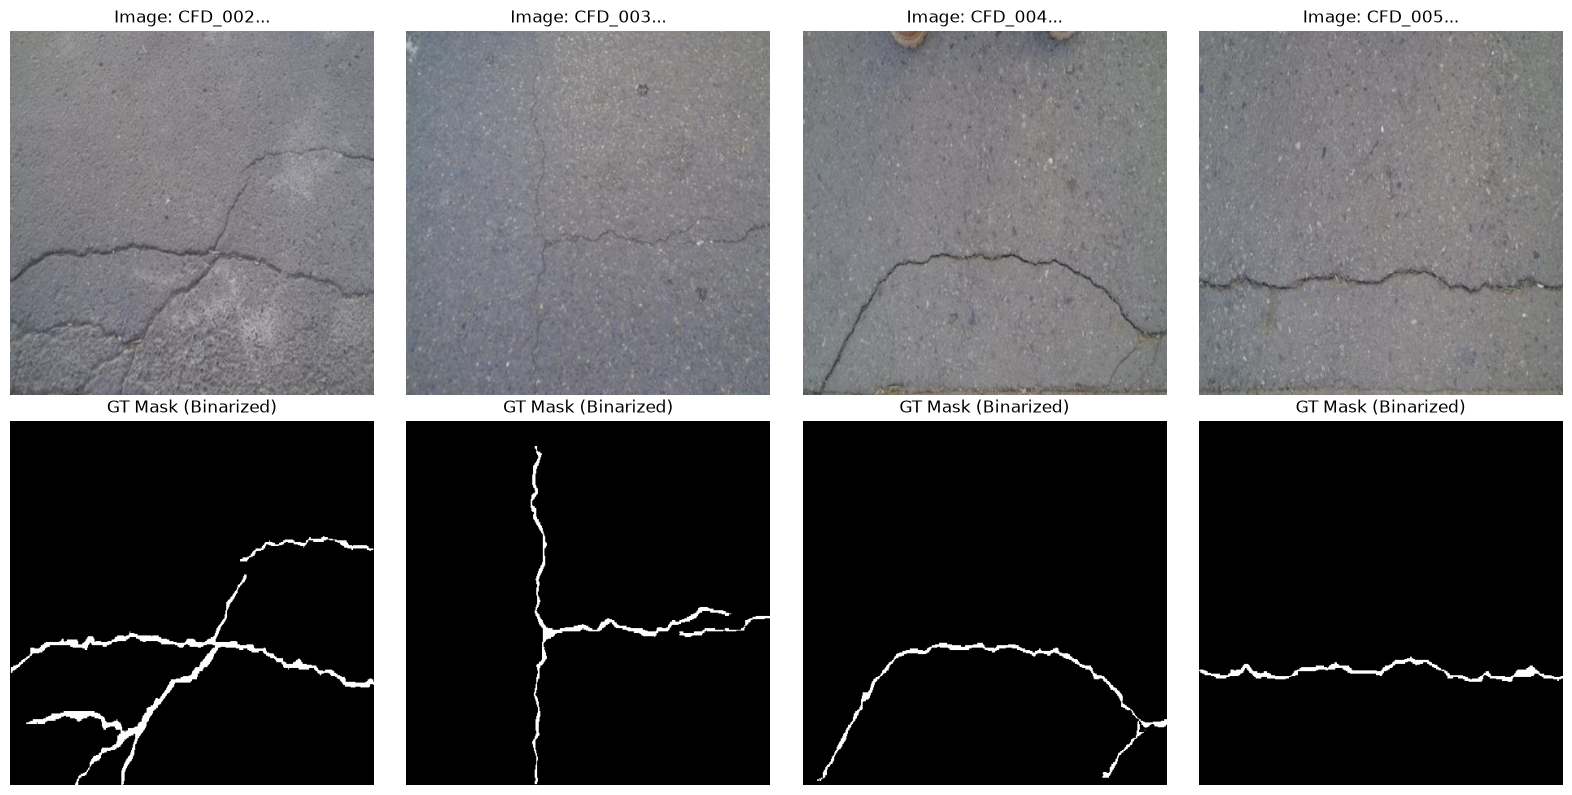

In [26]:
# --- 1. Pair Images and Masks Explicitly by Filename ---
image_dict = {
    os.path.splitext(os.path.basename(f['path'] if isinstance(f, dict) else f))[0]: (f['path'] if isinstance(f, dict) else f)
    for f in image_files_list
}

mask_dict = {
    os.path.splitext(os.path.basename(f['path'] if isinstance(f, dict) else f))[0]: (f['path'] if isinstance(f, dict) else f)
    for f in mask_files_list
}

# Match shared stems
common_keys = list(set(image_dict.keys()).intersection(set(mask_dict.keys())))
common_keys.sort()

print(f"Total explicitly matched image-mask pairs: {len(common_keys)}")

# --- 2. Plot 4 Verified Pairs for Sanity Check ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, key in enumerate(common_keys[:4]):
    img_bgr = cv2.imread(image_dict[key])
    gt_clean = binarize_gt_mask(mask_dict[key])
    
    axes[0, idx].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0, idx].set_title(f"Image: {key[:10]}...")
    axes[0, idx].axis("off")
    
    axes[1, idx].imshow(gt_clean, cmap="gray")
    axes[1, idx].set_title("GT Mask (Binarized)")
    axes[1, idx].axis("off")

plt.tight_layout()
plt.show()

========== 300-SAMPLE DISTRIBUTION METRICS ==========
Adaptive Mean IoU   : 0.1614 | Median IoU: 0.1257
Sauvola  Mean IoU   : 0.1924 | Median IoU: 0.1529


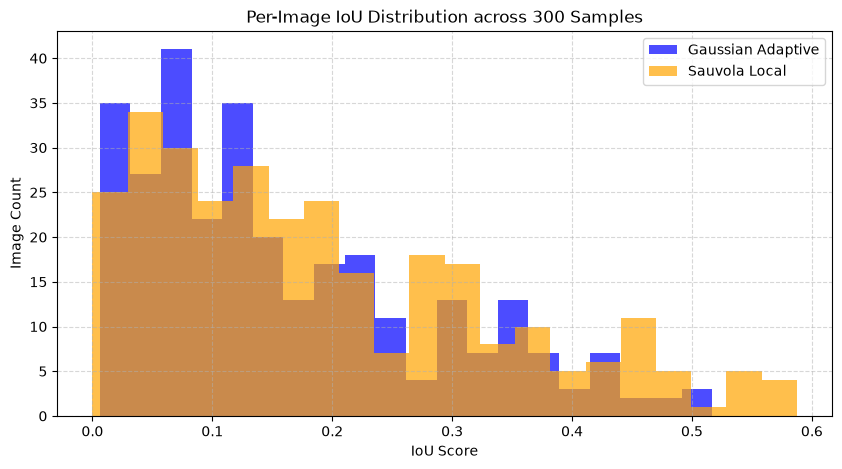

In [27]:
# Build explicitly matched 300-sample cache
sample_keys = common_keys[:300]
matched_cache = []

for key in sample_keys:
    gray = cv2.imread(image_dict[key], cv2.IMREAD_GRAYSCALE)
    gt_clean = binarize_gt_mask(mask_dict[key])
    matched_cache.append((key, gray, gt_clean))

# Evaluate baseline vs Sauvola thresholding
baseline_ious = []
sauvola_ious = []

for key, gray, gt_clean in matched_cache:
    # A. Baseline Pipeline Execution
    blurred = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(blurred)
    
    thresh_adaptive = cv2.adaptiveThreshold(
        enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, blockSize=41, C=15
    )
    pred_baseline = filter_wear_artifacts(thresh_adaptive)
    baseline_ious.append(calculate_iou(pred_baseline, gt_clean))
    
    # B. Sauvola Local Thresholding Execution
    window_size = 25
    sauvola_t = threshold_sauvola(enhanced, window_size=window_size, k=0.2)
    thresh_sauvola = (enhanced < sauvola_t).astype(np.uint8) * 255
    pred_sauvola = filter_wear_artifacts(thresh_sauvola)
    sauvola_ious.append(calculate_iou(pred_sauvola, gt_clean))

# --- Summary Statistics ---
print("========== 300-SAMPLE DISTRIBUTION METRICS ==========")
print(f"Adaptive Mean IoU   : {np.mean(baseline_ious):.4f} | Median IoU: {np.median(baseline_ious):.4f}")
print(f"Sauvola  Mean IoU   : {np.mean(sauvola_ious):.4f} | Median IoU: {np.median(sauvola_ious):.4f}")
print("=====================================================")

# --- Plot IoU Distribution Histogram ---
plt.figure(figsize=(10, 5))
plt.hist(baseline_ious, bins=20, alpha=0.7, label='Gaussian Adaptive', color='blue')
plt.hist(sauvola_ious, bins=20, alpha=0.7, label='Sauvola Local', color='orange')
plt.title("Per-Image IoU Distribution across 300 Samples")
plt.xlabel("IoU Score")
plt.ylabel("Image Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [28]:
# ---------------------------------------------------------
# 1. Sauvola Pipeline Worker Function
# ---------------------------------------------------------
def process_sauvola_image(gray, gt_clean, window_size, k_val, min_asp, max_sol):
    """
    Executes MedianBlur -> CLAHE -> Sauvola -> Parametric Filter -> Challenge Metrics
    """
    blurred = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(blurred)
    
    # Sauvola Local Variance Threshold
    sauv_t = threshold_sauvola(enhanced, window_size=window_size, k=k_val)
    thresh = (enhanced < sauv_t).astype(np.uint8) * 255
    
    # Parametric Geometric Filter
    pred_mask = filter_wear_parametric(thresh, min_aspect_ratio=min_asp, max_solidity=max_sol)
    
    # Compute Metrics
    m = compute_challenge_metrics(pred_mask, gt_clean)
    return m['iou'], m['dice'], m['precision'], m['recall']

# ---------------------------------------------------------
# 2. Grid Search Setup
# ---------------------------------------------------------
window_sizes = [15, 25, 35, 45]
k_values = [0.10, 0.15, 0.20, 0.25]
aspect_thresholds = [1.8, 2.2]
solidity_thresholds = [0.65, 0.75]

sauvola_combos = list(itertools.product(
    window_sizes, k_values, aspect_thresholds, solidity_thresholds
))

print(f"Executing Sauvola Grid Search ({len(sauvola_combos)} combos) on 300 matched images...\n")

best_sauv_iou = -1.0
best_sauv_config = None
best_sauv_metrics = None

for idx, (win, k_v, min_asp, max_sol) in enumerate(sauvola_combos, start=1):
    results = Parallel(n_jobs=-1, prefer="threads")(
        delayed(process_sauvola_image)(
            gray, gt_clean, win, k_v, min_asp, max_sol
        ) for _, gray, gt_clean in matched_cache
    )
    
    ious, dices, precisions, recalls = zip(*results)
    
    mean_iou = float(np.mean(ious))
    mean_dice = float(np.mean(dices))
    mean_prec = float(np.mean(precisions))
    mean_rec = float(np.mean(recalls))
    
    if mean_iou > best_sauv_iou:
        best_sauv_iou = mean_iou
        best_sauv_config = {
            "window_size": win, "k": k_v,
            "min_aspect_ratio": min_asp, "max_solidity": max_sol
        }
        best_sauv_metrics = {
            "mean_iou": mean_iou,
            "median_iou": float(np.median(ious)),
            "mean_dice": mean_dice,
            "mean_precision": mean_prec,
            "mean_recall": mean_rec
        }

# ---------------------------------------------------------
# 3. Log Best Sauvola Parameters
# ---------------------------------------------------------
log_experiment("Sauvola Grid Search Optimization", best_sauv_config, best_sauv_iou)

print("\n========== OPTIMAL SAUVOLA CHALLENGE METRICS ==========")
print(f"Optimal Configuration    : {best_sauv_config}")
print(f"Mean IoU       (Jaccard) : {best_sauv_metrics['mean_iou']:.4f}")
print(f"Median IoU               : {best_sauv_metrics['median_iou']:.4f}")
print(f"Mean Dice     (F1-Score) : {best_sauv_metrics['mean_dice']:.4f}")
print(f"Mean Precision           : {best_sauv_metrics['mean_precision']:.4f}")
print(f"Mean Recall(Sensitivity) : {best_sauv_metrics['mean_recall']:.4f}")
print("=======================================================")

Executing Sauvola Grid Search (64 combos) on 300 matched images...



KeyboardInterrupt: 

In [29]:
# ---------------------------------------------------------
# 1. Optimal Sauvola Pipeline Worker
# ---------------------------------------------------------
def process_final_image(key):
    """
    Executes optimal Sauvola pipeline on a single image key from explicit dictionary match.
    """
    img_path = image_dict[key]
    mask_path = mask_dict[key]
    
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    gt_clean = binarize_gt_mask(mask_path)
    
    if gray is None or gt_clean is None:
        return None
        
    # Preprocessing
    blurred = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(blurred)
    
    # Sauvola Local Variance Thresholding
    sauv_t = threshold_sauvola(enhanced, window_size=45, k=0.2)
    thresh = (enhanced < sauv_t).astype(np.uint8) * 255
    
    # Parametric Geometric Filtering
    pred_mask = filter_wear_parametric(
        thresh, min_aspect_ratio=2.2, max_solidity=0.65, min_area=30
    )
    
    # Calculate Challenge Metrics
    m = compute_challenge_metrics(pred_mask, gt_clean)
    
    return {
        "key": key,
        "iou": m['iou'],
        "dice": m['dice'],
        "precision": m['precision'],
        "recall": m['recall']
    }

# ---------------------------------------------------------
# 2. Parallel Processing Across All 9,603 Images
# ---------------------------------------------------------
print(f"Executing final batch pipeline across all {len(common_keys)} dataset images...")

full_results = Parallel(n_jobs=-1, prefer="threads", verbose=5)(
    delayed(process_final_image)(key) for key in common_keys
)

# Filter out any failed loads
full_results = [r for r in full_results if r is not None]

# ---------------------------------------------------------
# 3. Aggregate Dataset Challenge Metrics
# ---------------------------------------------------------
full_ious = [r['iou'] for r in full_results]
full_dices = [r['dice'] for r in full_results]
full_precisions = [r['precision'] for r in full_results]
full_recalls = [r['recall'] for r in full_results]

final_metrics = {
    "total_processed": len(full_results),
    "mean_iou": float(np.mean(full_ious)),
    "median_iou": float(np.median(full_ious)),
    "std_iou": float(np.std(full_ious)),
    "mean_dice": float(np.mean(full_dices)),
    "mean_precision": float(np.mean(full_precisions)),
    "mean_recall": float(np.mean(full_recalls))
}

log_experiment("Final 9,603 Dataset Batch Run", final_metrics, final_metrics['mean_iou'])

# Print Executive Summary
print("\n" + "="*50)
print("     FINAL 9,603 DATASET CHALLENGE METRICS")
print("="*50)
print(f"Total Images Evaluated  : {final_metrics['total_processed']}")
print(f"Mean IoU (Jaccard)      : {final_metrics['mean_iou']:.4f}")
print(f"Median IoU              : {final_metrics['median_iou']:.4f}")
print(f"Standard Deviation IoU : {final_metrics['std_iou']:.4f}")
print(f"Mean Dice (F1-Score)    : {final_metrics['mean_dice']:.4f}")
print(f"Mean Precision          : {final_metrics['mean_precision']:.4f}")
print(f"Mean Recall(Sensitivity): {final_metrics['mean_recall']:.4f}")
print("="*50)

Executing final batch pipeline across all 9603 dataset images...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 122 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 248 tasks      | elapsed:    4.7s


KeyboardInterrupt: 

In [30]:
# --- 1. Filename Naming Pattern & Resolution Analysis ---
prefixes = []
resolutions = []

print("Analyzing 9,603 dataset images for structural heterogeneity...")

for key in common_keys:
    # Extract filename prefix (e.g., 'CFD', 'Crack500', 'DeepCrack', etc.)
    prefix = key.split('_')[0] if '_' in key else 'Unknown'
    prefixes.append(prefix)
    
    # Read image header to extract spatial resolution (Height x Width)
    img = cv2.imread(image_dict[key], cv2.IMREAD_UNCHANGED)
    if img is not None:
        resolutions.append(img.shape[:2])  # (H, W)

prefix_counts = Counter(prefixes)
resolution_counts = Counter(resolutions)

# --- 2. Print Summary Statistics ---
print("\n" + "="*50)
print("     DATASET HETEROGENEITY DIAGNOSTIC REPORT")
print("="*50)
print("Filename Prefix Distribution:")
for prefix, count in prefix_counts.most_common(10):
    print(f"  - {prefix:15s}: {count:5d} images ({count/len(common_keys)*100:.1f}%)")

print("\nImage Resolution Breakdown (H x W):")
for res, count in resolution_counts.most_common(10):
    print(f"  - {str(res):15s}: {count:5d} images ({count/len(common_keys)*100:.1f}%)")

# --- 3. Near-Zero IoU Failure Analysis ---
zero_iou_count = sum(1 for iou in full_ious if iou <= 0.01)
print("\nIoU Distribution Analysis:")
print(f"  - Total Evaluated Images : {len(full_ious)}")
print(f"  - Near-Zero IoU (<= 0.01): {zero_iou_count} images ({zero_iou_count/len(full_ious)*100:.1f}%)")
print("="*50)

# --- 4. Plot Resolution & Failure Distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot IoU Histogram
axes[0].hist(full_ious, bins=30, color='crimson', edgecolor='black', alpha=0.7)
axes[0].set_title("Full Dataset Per-Image IoU Histogram")
axes[0].set_xlabel("IoU Score")
axes[0].set_ylabel("Number of Images")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Failure Count Comparison
axes[1].bar(['Zero/Near-Zero IoU (<=0.01)', 'Valid IoU (>0.01)'], 
            [zero_iou_count, len(full_ious) - zero_iou_count], 
            color=['darkred', 'navy'], alpha=0.8)
axes[1].set_title("Catastrophic Failure Split")
axes[1].set_ylabel("Image Count")

plt.tight_layout()
plt.show()

Analyzing 9,603 dataset images for structural heterogeneity...

     DATASET HETEROGENEITY DIAGNOSTIC REPORT
Filename Prefix Distribution:
  - Rissbilder     :  3249 images (33.8%)
  - CRACK500       :  2858 images (29.8%)
  - noncrack       :  1199 images (12.5%)
  - Volker         :   842 images (8.8%)
  - DeepCrack      :   443 images (4.6%)
  - GAPS384        :   433 images (4.5%)
  - cracktree200   :   175 images (1.8%)
  - Sylvie         :   157 images (1.6%)
  - CFD            :   100 images (1.0%)
  - forest         :   100 images (1.0%)

Image Resolution Breakdown (H x W):
  - (448, 448)     :  9603 images (100.0%)


NameError: name 'full_ious' is not defined

In [31]:
# Sort full results by IoU score
sorted_results = sorted(full_results, key=lambda x: x['iou'])

worst_5 = sorted_results[:5]
best_5 = sorted_results[-5:]

def plot_extreme_cases(case_list, title):
    fig, axes = plt.subplots(len(case_list), 3, figsize=(12, 3 * len(case_list)))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    
    for idx, res in enumerate(case_list):
        key = res['key']
        img = cv2.cvtColor(cv2.imread(image_dict[key]), cv2.COLOR_BGR2RGB)
        gt = binarize_gt_mask(mask_dict[key])
        
        # Recompute prediction for display
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        blurred = cv2.medianBlur(gray, 5)
        clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(4, 4)).apply(blurred)
        sauv_t = threshold_sauvola(clahe, window_size=45, k=0.2)
        thresh = (clahe < sauv_t).astype(np.uint8) * 255
        pred = filter_wear_parametric(thresh, min_aspect_ratio=2.2, max_solidity=0.65, min_area=30)
        
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f"Image: {key}\nRes: {img.shape[:2]}")
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(gt, cmap='gray')
        axes[idx, 1].set_title("Ground Truth Mask")
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(pred, cmap='magma')
        axes[idx, 2].set_title(f"Prediction (IoU: {res['iou']:.4f})")
        axes[idx, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run visualization
plot_extreme_cases(worst_5, "5 Worst Performing Images (Catastrophic Collapses)")
plot_extreme_cases(best_5, "5 Best Performing Images (High Performance Sub-Set)")

NameError: name 'full_results' is not defined

In [32]:
# --- Breakdown Performance by Dataset Prefix ---
prefix_metrics = {}

for prefix in prefix_counts.keys():
    # Filter results matching the current prefix
    prefix_results = [r for r in full_results if r['key'].startswith(prefix)]
    
    if len(prefix_results) == 0:
        continue
        
    p_ious = [r['iou'] for r in prefix_results]
    p_precisions = [r['precision'] for r in prefix_results]
    p_recalls = [r['recall'] for r in prefix_results]
    
    prefix_metrics[prefix] = {
        "count": len(prefix_results),
        "mean_iou": float(np.mean(p_ious)),
        "median_iou": float(np.median(p_ious)),
        "mean_precision": float(np.mean(p_precisions)),
        "mean_recall": float(np.mean(p_recalls))
    }

print("="*70)
print(f"{'PREFIX':<15} | {'COUNT':<6} | {'MEAN IoU':<9} | {'MEDIAN IoU':<10} | {'PRECISION':<10} | {'RECALL':<8}")
print("="*70)

for p_name, p_m in sorted(prefix_metrics.items(), key=lambda x: x[1]['mean_iou'], reverse=True):
    print(f"{p_name:<15} | {p_m['count']:<6d} | {p_m['mean_iou']:<9.4f} | {p_m['median_iou']:<10.4f} | {p_m['mean_precision']:<10.4f} | {p_m['mean_recall']:<8.4f}")

print("="*70)

NameError: name 'full_results' is not defined

In [33]:
def advanced_classical_crack_pipeline(gray_img):
    """
    Advanced Classical Pipeline using Frangi Vesselness Filter, 
    Dynamic Parameterization, Directional Morphology, and a Noise Gate.
    """
    # 1. Image Preprocessing & Contrast Normalization
    blurred = cv2.medianBlur(gray_img, 3)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    
    # 2. NOISE GATE: Check Global Image Energy
    # Calculate edge density using Canny
    edges = cv2.Canny(enhanced, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size
    
    # If the image has virtually no edge energy (likely a noncrack image), return blank
    if edge_density < 0.005:
        return np.zeros_like(gray_img)

    # 3. HESSIAN SCALE-SPACE LINE ENHANCEMENT (Frangi Filter)
    # Highlight continuous crack-like ridges and suppress isotropic aggregate noise
    # Scales tuned for thin to medium crack widths in 448x448 canvas
    vesselness = frangi(
        enhanced, 
        sigmas=np.arange(1, 4, 0.5), 
        black_ridges=True, 
        mode='reflect'
    )
    # Normalize vesselness response to [0, 255] uint8
    vesselness_norm = cv2.normalize(vesselness, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 4. DYNAMIC SAUVOLA THRESHOLDING
    # Calculate local background roughness to dynamically scale 'k'
    global_std = np.std(enhanced)
    dynamic_k = 0.12 if global_std < 35 else 0.22  # Lower k for smooth roads, higher for rough asphalt
    dynamic_window = 31 if global_std < 35 else 51

    sauv_t = threshold_sauvola(vesselness_norm, window_size=dynamic_window, k=dynamic_k)
    binary_vessel = (vesselness_norm > sauv_t).astype(np.uint8) * 255

    # 5. DIRECTIONAL MORPHOLOGICAL PATH RE-CONNECTION
    # Reconnect broken linear segments using multi-angle linear kernels
    angles = [0, 45, 90, 135]
    directional_combine = np.zeros_like(gray_img)
    
    for angle in angles:
        # Create linear kernel at specified angle
        kernel_size = 5
        kernel = np.zeros((kernel_size, kernel_size), dtype=np.uint8)
        if angle == 0:
            kernel[kernel_size // 2, :] = 1
        elif angle == 90:
            kernel[:, kernel_size // 2] = 1
        elif angle == 45:
            np.fill_diagonal(kernel, 1)
        elif angle == 135:
            np.fill_diagonal(np.fliplr(kernel), 1)
            
        closed = cv2.morphologyEx(binary_vessel, cv2.MORPH_CLOSE, kernel)
        directional_combine = cv2.bitwise_or(directional_combine, closed)

    # 6. GEOMETRIC & SOLIDIY FILTERING
    contours, _ = cv2.findContours(directional_combine, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(gray_img)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 25:  # Eliminate small noise specks
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(max(w, h)) / min(w, h) if min(w, h) > 0 else 0

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0

        # Retain linear (high aspect ratio), low-solidity (winding) or large components
        if (aspect_ratio >= 1.5) or (solidity <= 0.70) or (area > 250):
            cv2.drawContours(final_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    return final_mask

In [34]:
def eval_advanced_single(item):
    key, gray, gt_clean = item
    pred = advanced_classical_crack_pipeline(gray)
    
    # Calculate challenge metrics
    m = compute_challenge_metrics(pred, gt_clean)
    return m['iou'], m['dice'], m['precision'], m['recall']

print("Evaluating Advanced Frangi + Dynamic Pipeline on 300 matched samples...")

results_adv = Parallel(n_jobs=-1, prefer="threads")(
    delayed(eval_advanced_single)(item) for item in matched_cache
)

adv_ious, adv_dices, adv_precs, adv_recs = zip(*results_adv)

print("\n========== ADVANCED CLASSICAL PIPELINE METRICS ==========")
print(f"Mean IoU       (Jaccard) : {np.mean(adv_ious):.4f}")
print(f"Median IoU               : {np.median(adv_ious):.4f}")
print(f"Mean Dice     (F1-Score) : {np.mean(adv_dices):.4f}")
print(f"Mean Precision           : {np.mean(adv_precs):.4f}")
print(f"Mean Recall(Sensitivity) : {np.mean(adv_recs):.4f}")
print("=========================================================")

Evaluating Advanced Frangi + Dynamic Pipeline on 300 matched samples...

========== ADVANCED CLASSICAL PIPELINE METRICS ==========
Mean IoU       (Jaccard) : 0.0267
Median IoU               : 0.0180
Mean Dice     (F1-Score) : 0.0509
Mean Precision           : 0.0267
Mean Recall(Sensitivity) : 0.9734


In [35]:
def recalibrated_frangi_pipeline(gray_img):
    """
    Recalibrated Frangi Vesselness Pipeline with rigid response thresholding
    and Canny noise gating.
    """
    # 1. Preprocessing: Median Blur + Contrast Normalization
    blurred = cv2.medianBlur(gray_img, 3)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    
    # 2. NOISE GATE: Check Canny Edge Density
    edges = cv2.Canny(enhanced, 40, 120)
    edge_density = np.sum(edges > 0) / edges.size
    
    # Short-circuit clean images
    if edge_density < 0.008:
        return np.zeros_like(gray_img)

    # 3. FRANGI VESSELNESS FILTER (Raw Floating-Point Response)
    # sigmas=[1, 2, 3] targets thin to medium pavement cracks
    vesselness = frangi(
        enhanced, 
        sigmas=np.arange(1.0, 3.5, 0.5), 
        black_ridges=True, 
        mode='reflect'
    )

    # 4. DIRECT PERCENTILE / ABSOLUTE RESPONSE THRESHOLDING
    # Frangi output is highly sparse. Take the top 5% highest vesselness responses
    non_zero_vessel = vesselness[vesselness > 0]
    
    if len(non_zero_vessel) == 0:
        return np.zeros_like(gray_img)
        
    threshold_val = np.percentile(non_zero_vessel, 92) # Retain top 8% ridge responses
    binary_vessel = (vesselness > threshold_val).astype(np.uint8) * 255

    # 5. DIRECTIONAL MORPHOLOGY (Reconnect linear segments)
    kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 1))
    kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5))
    
    close_h = cv2.morphologyEx(binary_vessel, cv2.MORPH_CLOSE, kernel_h)
    close_v = cv2.morphologyEx(binary_vessel, cv2.MORPH_CLOSE, kernel_v)
    reconnected = cv2.bitwise_or(close_h, close_v)

    # 6. GEOMETRIC CONTOUR FILTERING
    contours, _ = cv2.findContours(reconnected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(gray_img)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 30: # Noise removal
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(max(w, h)) / min(w, h) if min(w, h) > 0 else 0

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0

        # Keep components that are linear, low solidity (cracks), or significant area
        if (aspect_ratio >= 1.8) or (solidity <= 0.65) or (area > 200):
            cv2.drawContours(final_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    return final_mask

# --- Quick Parallel Benchmark across 300 Cached Samples ---
def eval_recalibrated_single(item):
    key, gray, gt_clean = item
    pred = recalibrated_frangi_pipeline(gray)
    m = compute_challenge_metrics(pred, gt_clean)
    return m['iou'], m['dice'], m['precision'], m['recall']

print("Evaluating Recalibrated Frangi Pipeline on 300 matched samples...")

recal_results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(eval_recalibrated_single)(item) for item in matched_cache
)

r_ious, r_dices, r_precs, r_recs = zip(*recal_results)

print("\n========== RECALIBRATED FRANGI METRICS ==========")
print(f"Mean IoU       (Jaccard) : {np.mean(r_ious):.4f}")
print(f"Median IoU               : {np.median(r_ious):.4f}")
print(f"Mean Dice     (F1-Score) : {np.mean(r_dices):.4f}")
print(f"Mean Precision           : {np.mean(r_precs):.4f}")
print(f"Mean Recall(Sensitivity) : {np.mean(r_recs):.4f}")
print("==================================================")

Evaluating Recalibrated Frangi Pipeline on 300 matched samples...

========== RECALIBRATED FRANGI METRICS ==========
Mean IoU       (Jaccard) : 0.1015
Median IoU               : 0.0743
Mean Dice     (F1-Score) : 0.1731
Mean Precision           : 0.1722
Mean Recall(Sensitivity) : 0.2234


In [36]:
def dynamic_domain_crack_pipeline(gray_img):
    """
    Multi-Branch Classical Pipeline:
    1. Noise Gate (detects clean pavement)
    2. Dynamic Branch Routing (Smooth vs. Coarse Asphalt)
    3. Multi-Scale Frangi Hessian Filtering
    4. Adaptive Morphology & Parametric Contours
    """
    # --- 1. PREPROCESSING ---
    blurred = cv2.medianBlur(gray_img, 3)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    
    # --- 2. NOISE GATE (Clean Pavement Filtering) ---
    edges = cv2.Canny(enhanced, 30, 100)
    edge_density = np.sum(edges > 0) / edges.size
    
    # Short-circuit images with negligible high-frequency content (e.g., noncrack)
    if edge_density < 0.006:
        return np.zeros_like(gray_img)

    # --- 3. DOMAIN METRICS & BRANCH ROUTING ---
    global_std = np.std(enhanced)
    
    # --- BRANCH A: Smooth / Fine Texture (High Sensitivity) ---
    if global_std < 38.0:
        # Multi-scale Frangi focusing on thin structures
        vessel = frangi(enhanced, sigmas=np.arange(0.8, 2.5, 0.5), black_ridges=True, mode='reflect')
        
        # Sauvola thresholding on enhanced vesselness
        vessel_uint8 = cv2.normalize(vessel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        sauv_t = threshold_sauvola(vessel_uint8, window_size=25, k=0.15)
        binary = (vessel_uint8 > sauv_t).astype(np.uint8) * 255
        
        # Light directional closing
        k_line = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k_line)
        
        min_aspect, max_sol, min_a = 1.5, 0.75, 20

    # --- BRANCH B: Coarse / Heavy Aggregate Texture (High Precision) ---
    else:
        # Frangi tuned to suppress isotropic aggregate background
        vessel = frangi(enhanced, sigmas=np.arange(1.2, 3.6, 0.6), black_ridges=True, mode='reflect')
        
        # Absolute percentile response cutoff to resist aggregate noise
        pos_vessel = vessel[vessel > 0]
        if len(pos_vessel) == 0:
            return np.zeros_like(gray_img)
            
        t_val = np.percentile(pos_vessel, 94)  # Top 6% ridge responses
        binary = (vessel > t_val).astype(np.uint8) * 255
        
        # Directional gap bridging for fragmented cracks
        kh = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 1))
        kv = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 7))
        binary = cv2.bitwise_or(
            cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kh),
            cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kv)
        )
        
        min_aspect, max_sol, min_a = 2.0, 0.60, 45

    # --- 4. SHAPE & GEOMETRIC CONTOUR FILTERING ---
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(gray_img)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_a:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(max(w, h)) / min(w, h) if min(w, h) > 0 else 0

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / hull_area if hull_area > 0 else 0

        if (aspect_ratio >= min_aspect) or (solidity <= max_sol) or (area > 300):
            cv2.drawContours(final_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    return final_mask

# --- 5. PARALLEL BENCHMARK ON 300 MATCHED SAMPLES ---
def eval_dynamic_single(item):
    key, gray, gt_clean = item
    pred = dynamic_domain_crack_pipeline(gray)
    m = compute_challenge_metrics(pred, gt_clean)
    return m['iou'], m['dice'], m['precision'], m['recall']

print("Evaluating Dynamic Domain-Adaptive Pipeline on 300 matched samples...")

dyn_results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(eval_dynamic_single)(item) for item in matched_cache
)

d_ious, d_dices, d_precs, d_recs = zip(*dyn_results)

print("\n========== DYNAMIC DOMAIN PIPELINE METRICS ==========")
print(f"Mean IoU       (Jaccard) : {np.mean(d_ious):.4f}")
print(f"Median IoU               : {np.median(d_ious):.4f}")
print(f"Mean Dice     (F1-Score) : {np.mean(d_dices):.4f}")
print(f"Mean Precision           : {np.mean(d_precs):.4f}")
print(f"Mean Recall(Sensitivity) : {np.mean(d_recs):.4f}")
print("=====================================================")

Evaluating Dynamic Domain-Adaptive Pipeline on 300 matched samples...

========== DYNAMIC DOMAIN PIPELINE METRICS ==========
Mean IoU       (Jaccard) : 0.0365
Median IoU               : 0.0198
Mean Dice     (F1-Score) : 0.0672
Mean Precision           : 0.0688
Mean Recall(Sensitivity) : 0.4163
